# Gaussian summary-dimension diagnostic comparisons

Combine the saved `S=D`, `S=2D`, and `S=4D` OOD results for the L2, Kernel, density, and Linf diagnostics. Log marginal-likelihood errors are displayed in base-10 units. Axis limits cover every finite observation with 5% padding; no quantile truncation is applied. Error thresholds are calibrated from NPE minus analytical-reference errors; set `NORMALIZE_BY_CALIBRATION_THRESHOLD` below to switch between raw and threshold-normalized errors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analysis.summary_dimension_data import (
    DIAGNOSTICS,
    load_comparison_data,
)


INFO:bayesflow:Using backend 'tensorflow'


In [2]:
project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
result_dir = project_dir / "results"

# True: divide each NPE-versus-analytical error by its calibrated threshold scale.
# False: retain the raw NPE-versus-analytical error units.
NORMALIZE_BY_CALIBRATION_THRESHOLD = False

summary_specs = [
    ("S=D", "20d_10n", result_dir / "ood_20d_10n"),
    ("S=2D", "40d_10n", result_dir / "ood_40d_10n"),
    ("S=4D", "80d_10n", result_dir / "ood_80d_10n"),
]

pmp_by_summary = {
    label: pd.read_csv(path / f"pmp_ambiguity_frame_{tag}.csv")
    for label, tag, path in summary_specs
}
logml_by_summary = {
    label: pd.read_csv(path / f"logml_distance_frame_{tag}.csv")
    for label, tag, path in summary_specs
}
posterior_by_summary = {
    label: pd.read_csv(path / f"posterior_distance_frame_{tag}.csv")
    for label, tag, path in summary_specs
}

comparison_data = load_comparison_data(
    diagnostics=DIAGNOSTICS,
    error_metrics=("log10_logml_error", "posterior_mmd", "pmp_error"),
)

for label, df in pmp_by_summary.items():
    print(
        label,
        "pmp", df.shape,
        "logml", logml_by_summary[label].shape,
        "posterior", posterior_by_summary[label].shape,
    )

comparison_data.groupby(
    ["error_metric", "diagnostic", "summary"], observed=True
).size().unstack("summary")

S=D pmp (600, 54) logml (2400, 11) posterior (2400, 11)
S=2D pmp (600, 50) logml (2400, 10) posterior (2400, 10)
S=4D pmp (600, 50) logml (2400, 10) posterior (2400, 10)


summary                        S=D  S=2D  S=4D
error_metric      diagnostic                  
log10_logml_error l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400
posterior_mmd     l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400
pmp_error         l2          2400  2400  2400
                  mmd         2400  2400  2400
                  density     2400  2400  2400
                  linf        2400  2400  2400

In [3]:
source_color = dict(zip(sd.SOURCE_MODELS, sd.SOURCE_COLORS, strict=False))
class_styles = {
    False: {"marker": "o", "size": 32, "label": "all high surprise"},
    True: {"marker": "D", "size": 48, "label": "at least one not high surprise"},
}

def scatter_by_class_and_source(ax, data, x, y):
    for flag, style in class_styles.items():
        group = data[data["at_least_one_not_extrapolative"] == flag]
        ax.scatter(
            x.loc[group.index],
            y.loc[group.index],
            c=group["source_model"].map(source_color),
            marker=style["marker"],
            s=style["size"],
            alpha=0.75,
            edgecolors="black",
            linewidths=0.55,
        )

def scatter_source_with_median(ax, data, x, y):
    for source in sd.SOURCE_MODELS:
        group = data[data["source_model"].eq(source)]
        if group.empty:
            continue
        color = source_color[source]
        x_values = x.loc[group.index]
        y_values = y.loc[group.index]
        ax.scatter(
            x_values, y_values,
            color=color, s=22, alpha=0.42,
            edgecolors="black", linewidths=0.25,
        )
        ax.scatter(
            [x_values.median()], [y_values.median()],
            color=color, marker="*", s=170, alpha=0.98,
            edgecolors="black", linewidths=0.75, zorder=6,
        )

def add_first_large_error(ax, data, x, y, error_bound=0.05):
    if error_bound is None or data.empty:
        return
    ordered = pd.DataFrame({"x": x.loc[data.index], "y": y.loc[data.index]}).dropna().sort_values("x")
    hit = ordered[np.abs(ordered["y"]) > error_bound].head(1)
    if hit.empty:
        return
    x0 = float(hit["x"].iloc[0])
    ax.axvline(x0, color="0.2", linestyle=":", linewidth=1.2)
    ax.text(x0, 0.96, f"{x0:.2g}", transform=ax.get_xaxis_transform(), ha="right", va="top", rotation=90, fontsize=20)

def max_pmp_error_within_rho(data, model, rho_max=1.0):
    rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
    error = data[f"signed_pmp_error_npe_{model}"]
    subset = (
        data.assign(_rho=rho, _error=error)
        .loc[lambda df: df["_rho"].le(rho_max)]
        .dropna(subset=["_rho", "_error"])
    )
    if subset.empty:
        return None
    row = subset.loc[subset["_error"].abs().idxmax()]
    return {
        "source_model": row["source_model"],
        "rho_at_error": float(row["_rho"]),
        "signed_error_within_rho": float(row["_error"]),
        "n_candidate_points": int(len(subset)),
    }

def collect_max_pmp_error_within_rho(pmp_by_panel, rho_max=1.0):
    rows = []
    for panel_label, data in pmp_by_panel.items():
        for model in sd.ASSUMED_MODELS:
            best = max_pmp_error_within_rho(data, model, rho_max=rho_max)
            if best is None:
                continue
            rows.append({
                "panel_label": panel_label,
                "assumed_model": model,
                "rho_max": float(rho_max),
                **best,
            })
    return pd.DataFrame(rows)

def add_rho_max_error_line(ax, rho_error_df, panel_label, model):
    if rho_error_df is None or rho_error_df.empty:
        return
    match = rho_error_df[
        rho_error_df["panel_label"].eq(panel_label)
        & rho_error_df["assumed_model"].eq(model)
    ]
    if match.empty:
        return
    y0 = float(match["signed_error_within_rho"].iloc[0])
    ax.axhline(y0, color="#882255", linestyle="--", linewidth=1.1)
    va = "bottom" if y0 >= 0 else "top"
    ax.text(
        0.98,
        y0,
        f"{y0:.2g}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va=va,
        fontsize=13,
        color="#882255",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 1.0},
    )

def add_distance_regions(ax, low, high, x_min, x_max):
    del x_min, x_max
    ax.axvspan(low, high, color=sd.TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    ax.axvline(low, color="0.45", linestyle=":", linewidth=0.9, zorder=1)
    ax.axvline(high, color="0.25", linestyle="--", linewidth=0.9, zorder=1)

def add_facet_strips(fig, axes, col_labels=None, row_labels=None):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_h = 0.034
    right_w = 0.052

    if col_labels is not None:
        for ax, label in zip(axes[0], col_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_h])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=18)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

    if row_labels is not None:
        for ax, label in zip(axes[:, -1], row_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x1 + pad, pos.y0, right_w, pos.height])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center", fontsize=16, linespacing=1.05)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

def legend_handles():
    class_handles = [
        Line2D([0], [0], marker=style["marker"], color="none", markerfacecolor="0.55", markeredgecolor="black", markersize=9, label=style["label"])
        for style in class_styles.values()
    ]
    model_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=source_color[source], markeredgecolor="black", markersize=9, label=source.upper())
        for source in sd.SOURCE_MODELS
    ]
    return class_handles, model_handles

def median_handle():
    return Line2D([0], [0], marker="*", color="none", markerfacecolor="white",
                  markeredgecolor="black", markersize=20, label="source median")

def add_bottom_legend(fig, include_class=True, include_median=False):
    class_handles, model_handles = legend_handles()
    if include_class:
        fig.legend(handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.075), ncol=2, frameon=False, fontsize=17)
        model_y = 0.0
    else:
        model_y = 0.035
    handles = model_handles + ([median_handle()] if include_median else [])
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, model_y), ncol=len(handles), frameon=False, fontsize=17)

def add_right_legend(fig, x=0.84):
    class_handles, model_handles = legend_handles()
    fig.legend(handles=class_handles, loc="center left", bbox_to_anchor=(x, 0.62), ncol=1, frameon=False, fontsize=17)
    fig.legend(handles=model_handles, loc="center left", bbox_to_anchor=(x, 0.34), ncol=2, frameon=False, fontsize=17)

def style_panel_grid(fig, axes, xlabel_by_col, ylabel, row_labels, col_labels, include_class_legend=True, include_median_legend=False):
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=16)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)

    for ax, xlabel in zip(axes[-1], xlabel_by_col, strict=False):
        ax.set_xlabel(xlabel)

    fig.supylabel(ylabel, x=0.035, fontsize=20)
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=row_labels)
    add_bottom_legend(fig, include_class=include_class_legend, include_median=include_median_legend)


def error_display_columns(normalize_threshold):
    if normalize_threshold:
        return (
            "normalized_error_value",
            "normalized_error_lower_threshold",
            "normalized_error_upper_threshold",
        )
    return "error_value", "error_lower_threshold", "error_upper_threshold"


def calibration_error_ylabel(error_metric, normalize_threshold):
    reference = "normalized" if normalize_threshold else "analytical"
    if error_metric == "posterior_mmd":
        return f"Posterior MMD\n(NPE, {reference})"
    if error_metric == "log10_logml_error":
        return rf"$\log_{{10}}$ marginal-likelihood error" + f"\n(NPE − analytical, {reference})"
    if error_metric == "pmp_error":
        suffix = "calibration-normalized" if normalize_threshold else "NPE − analytical"
        return rf"$\widehat{{p}}(M_j\mid y)-p(M_j\mid y)$" + f"\n({suffix})"
    raise ValueError(f"Unknown error metric: {error_metric}")


def add_calibration_error_regions(ax, data, normalize_threshold):
    _, low_column, high_column = error_display_columns(normalize_threshold)
    thresholds = data[[low_column, high_column]].apply(pd.to_numeric, errors="coerce").dropna()
    if thresholds.empty:
        return
    low = float(thresholds[low_column].median())
    high = float(thresholds[high_column].median())
    if low > high:
        raise ValueError(f"Invalid calibration interval: [{low}, {high}]")
    ax.axhspan(low, high, color=sd.TYPICAL_SET_FILL, alpha=0.70, zorder=0)
    ax.axhline(low, color="0.30", linestyle="--", linewidth=1.0, zorder=1)
    if not np.isclose(low, high):
        ax.axhline(high, color="0.30", linestyle="--", linewidth=1.0, zorder=1)

l2: plotted rho in [-3.58, 22.6]
mmd: plotted rho in [-5.37, 9.05]
density: plotted rho in [-1.61, 116]
linf: plotted rho in [0, 15.7]


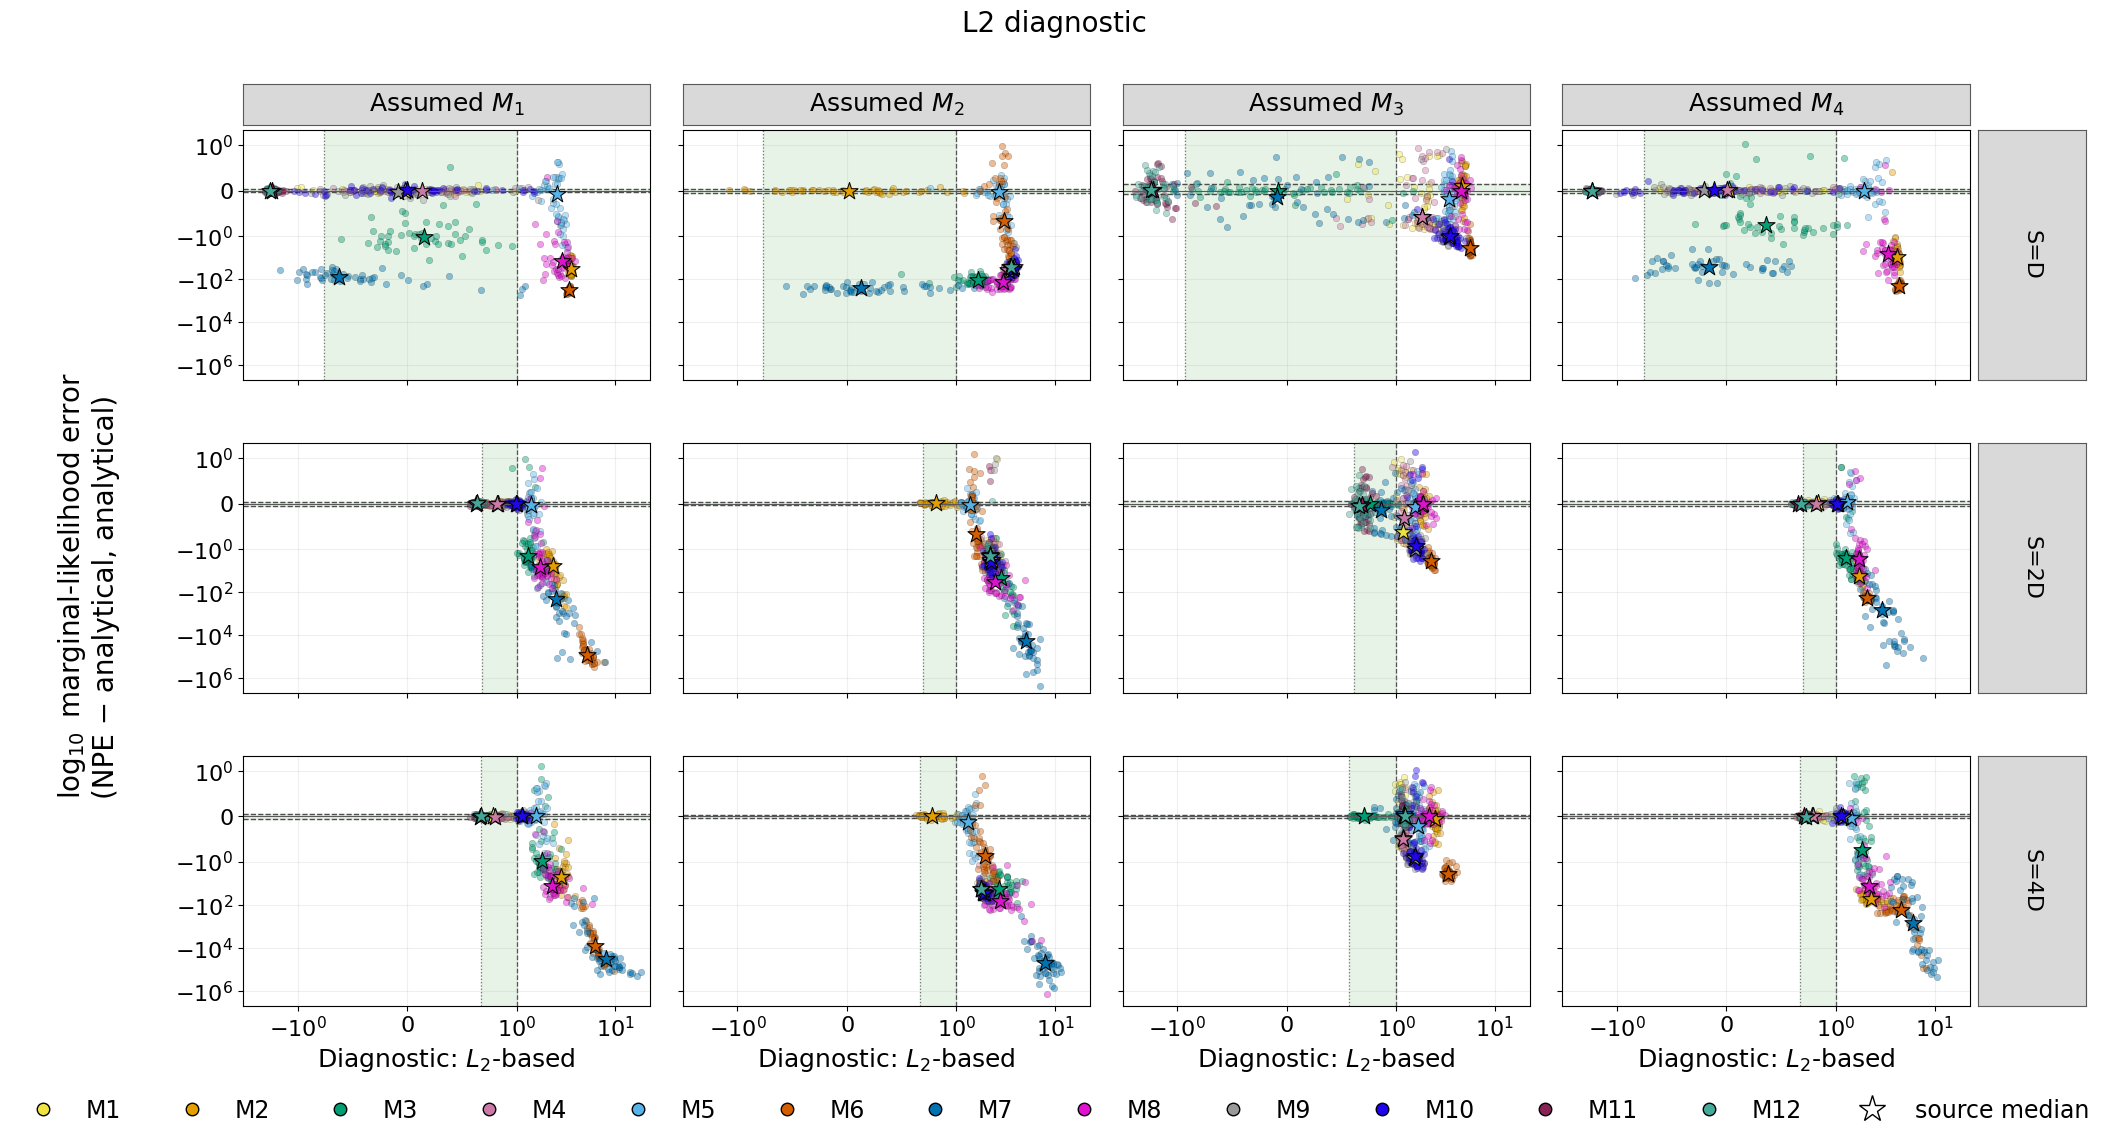

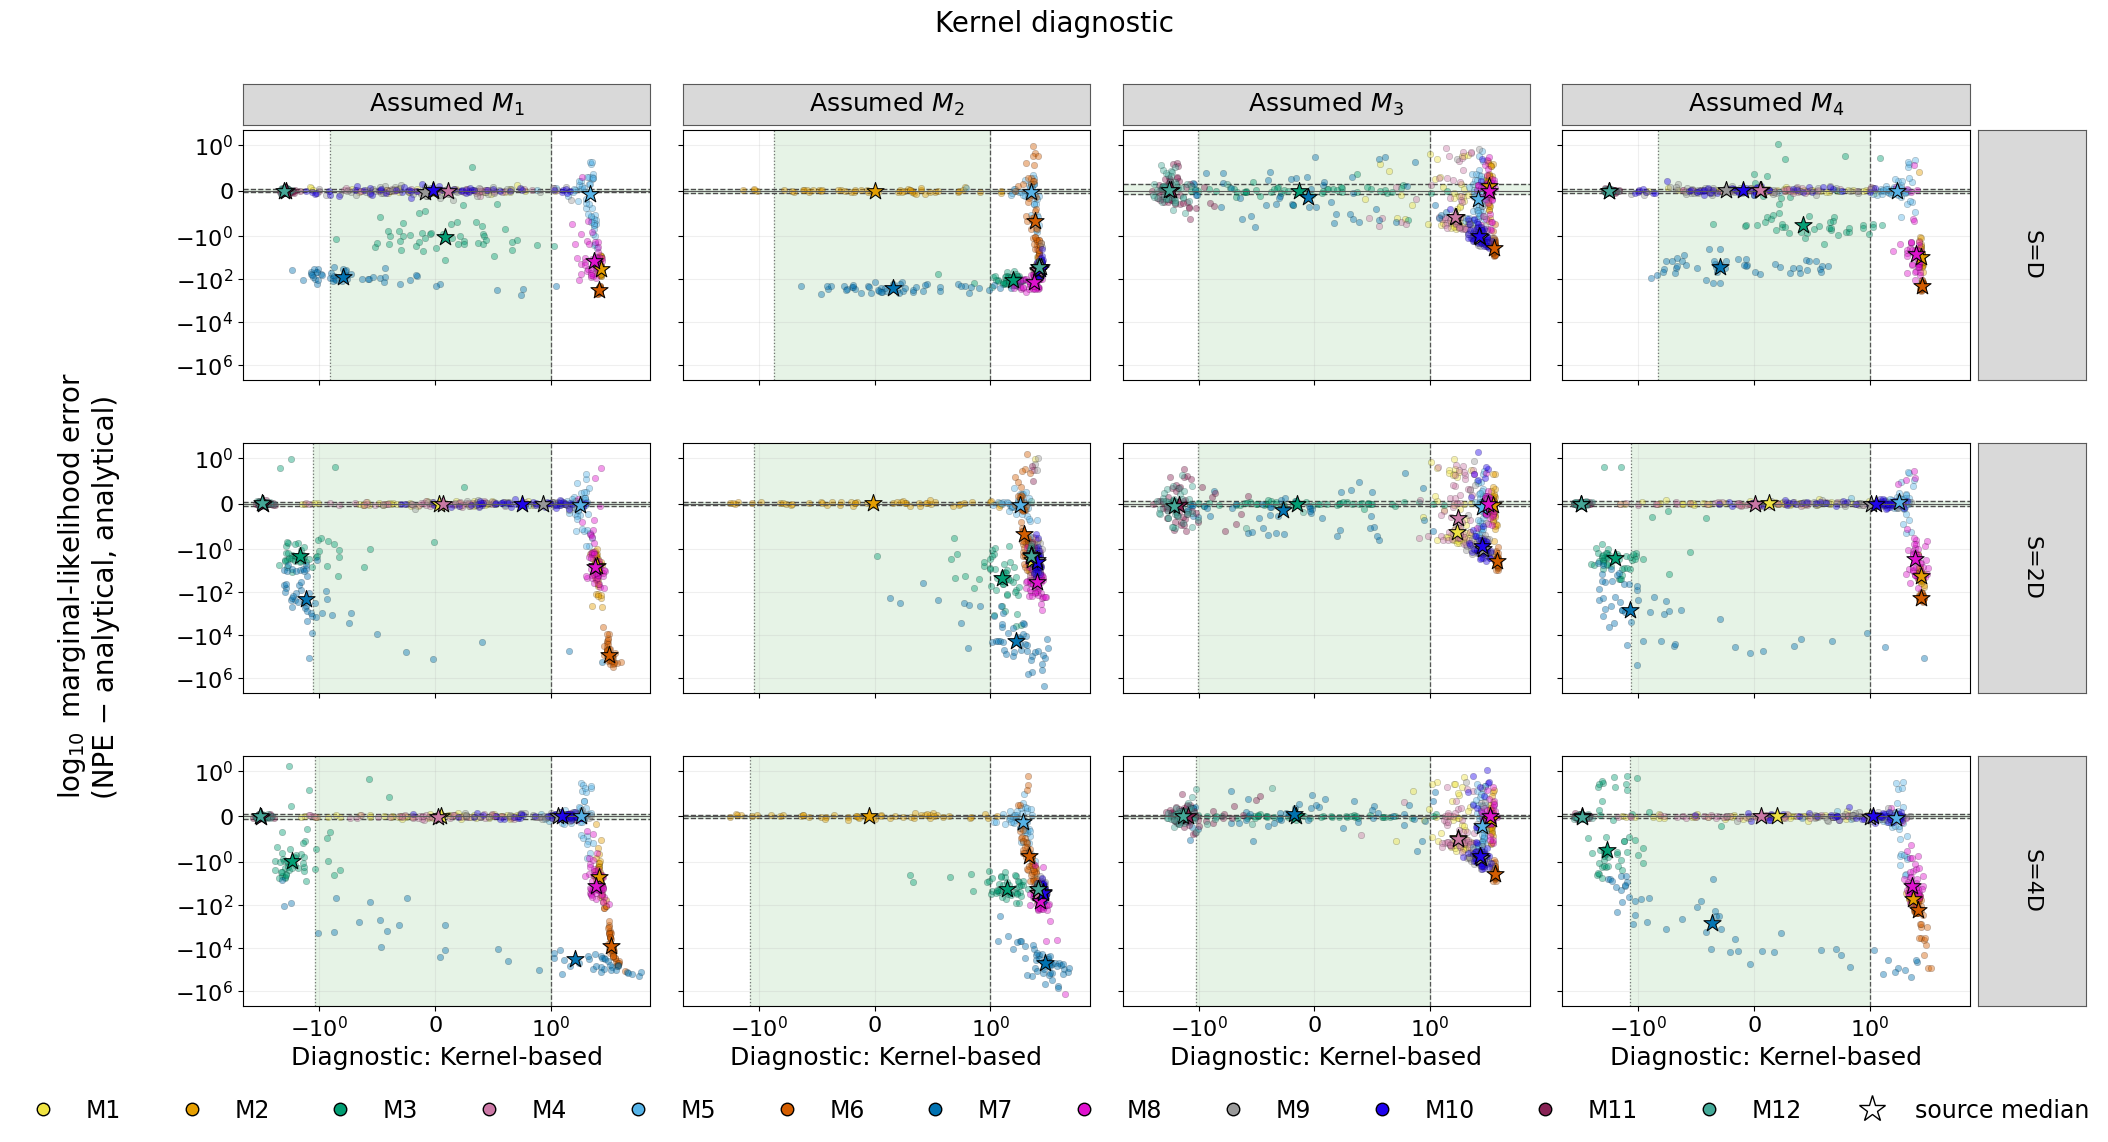

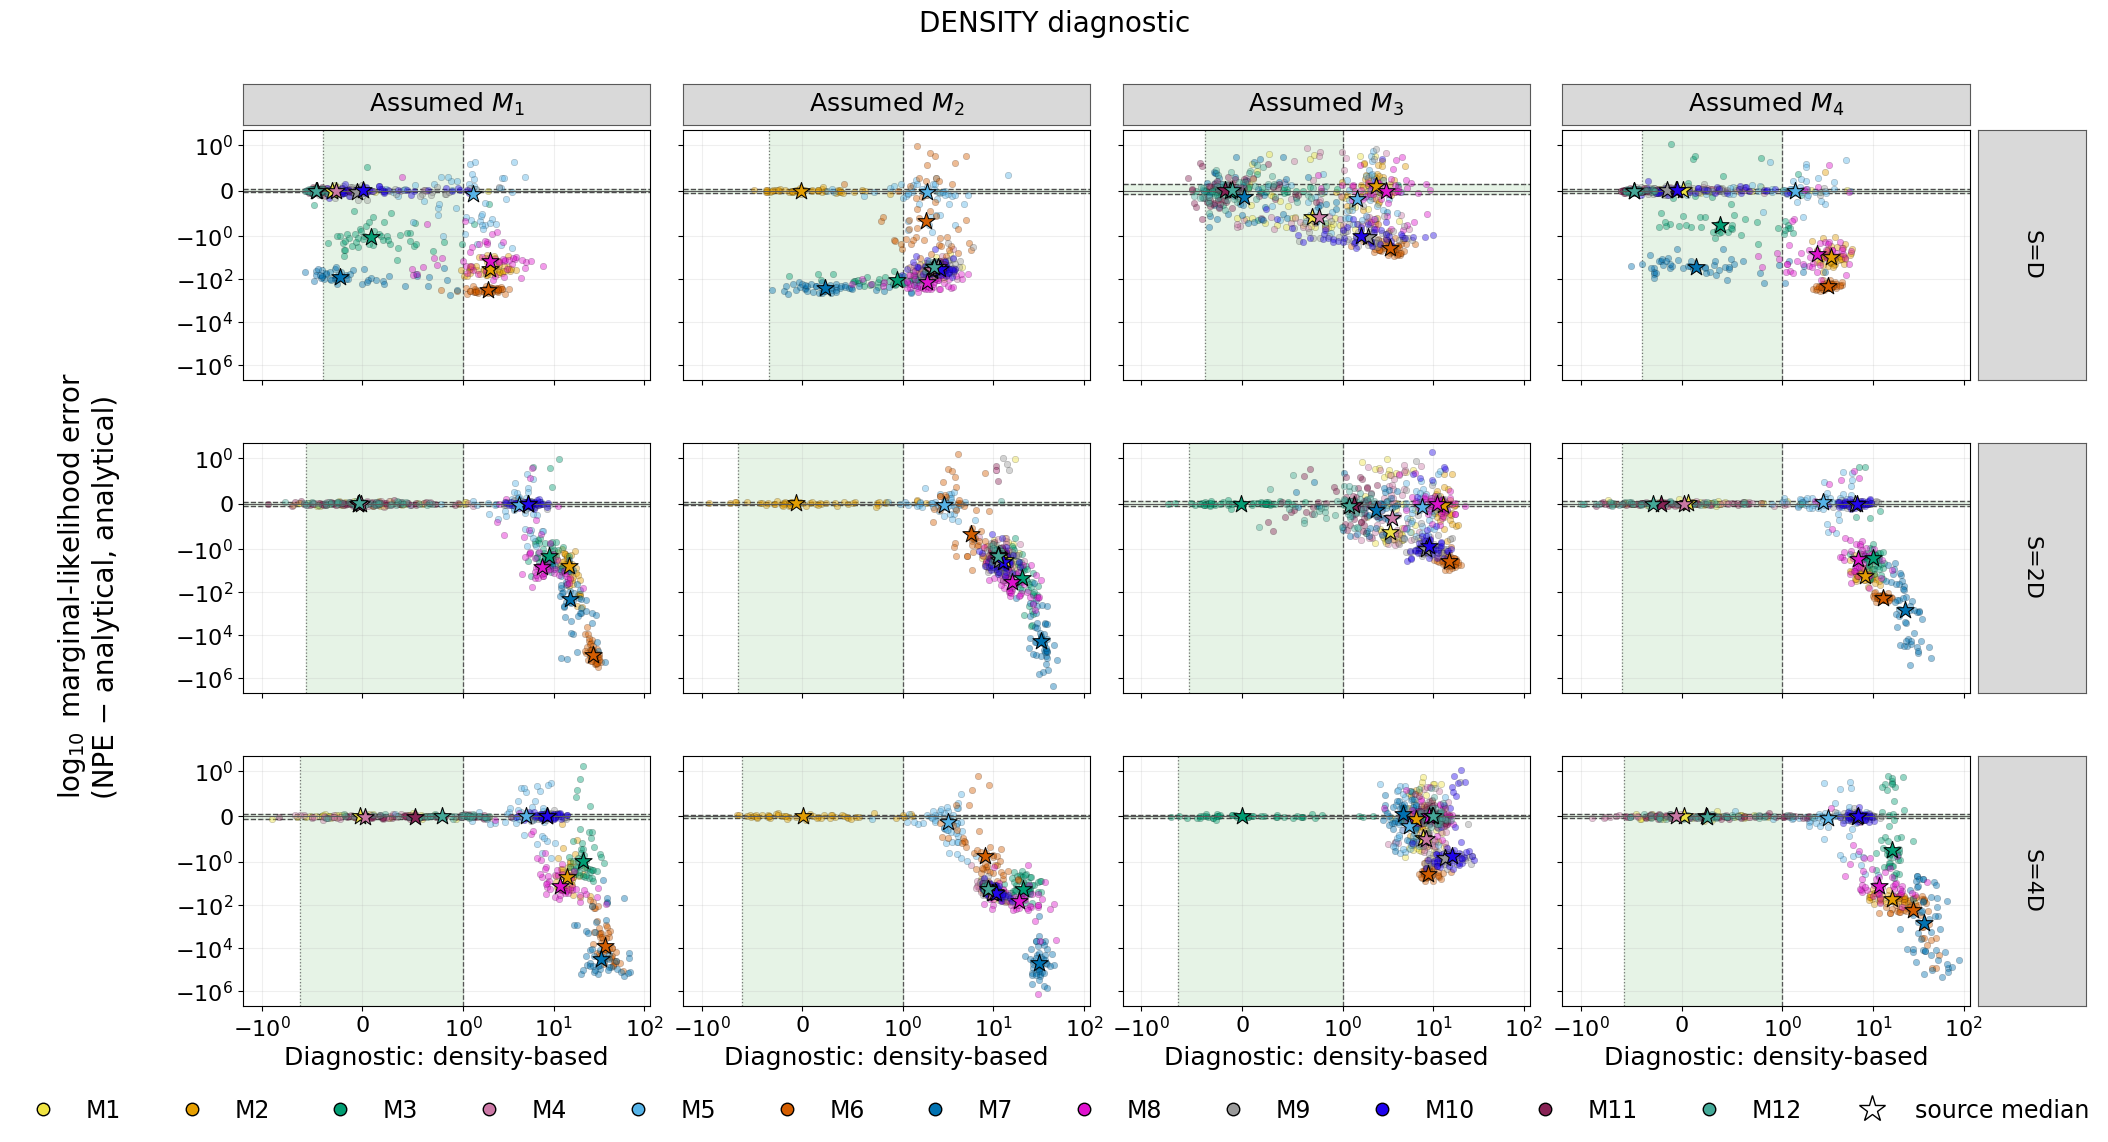

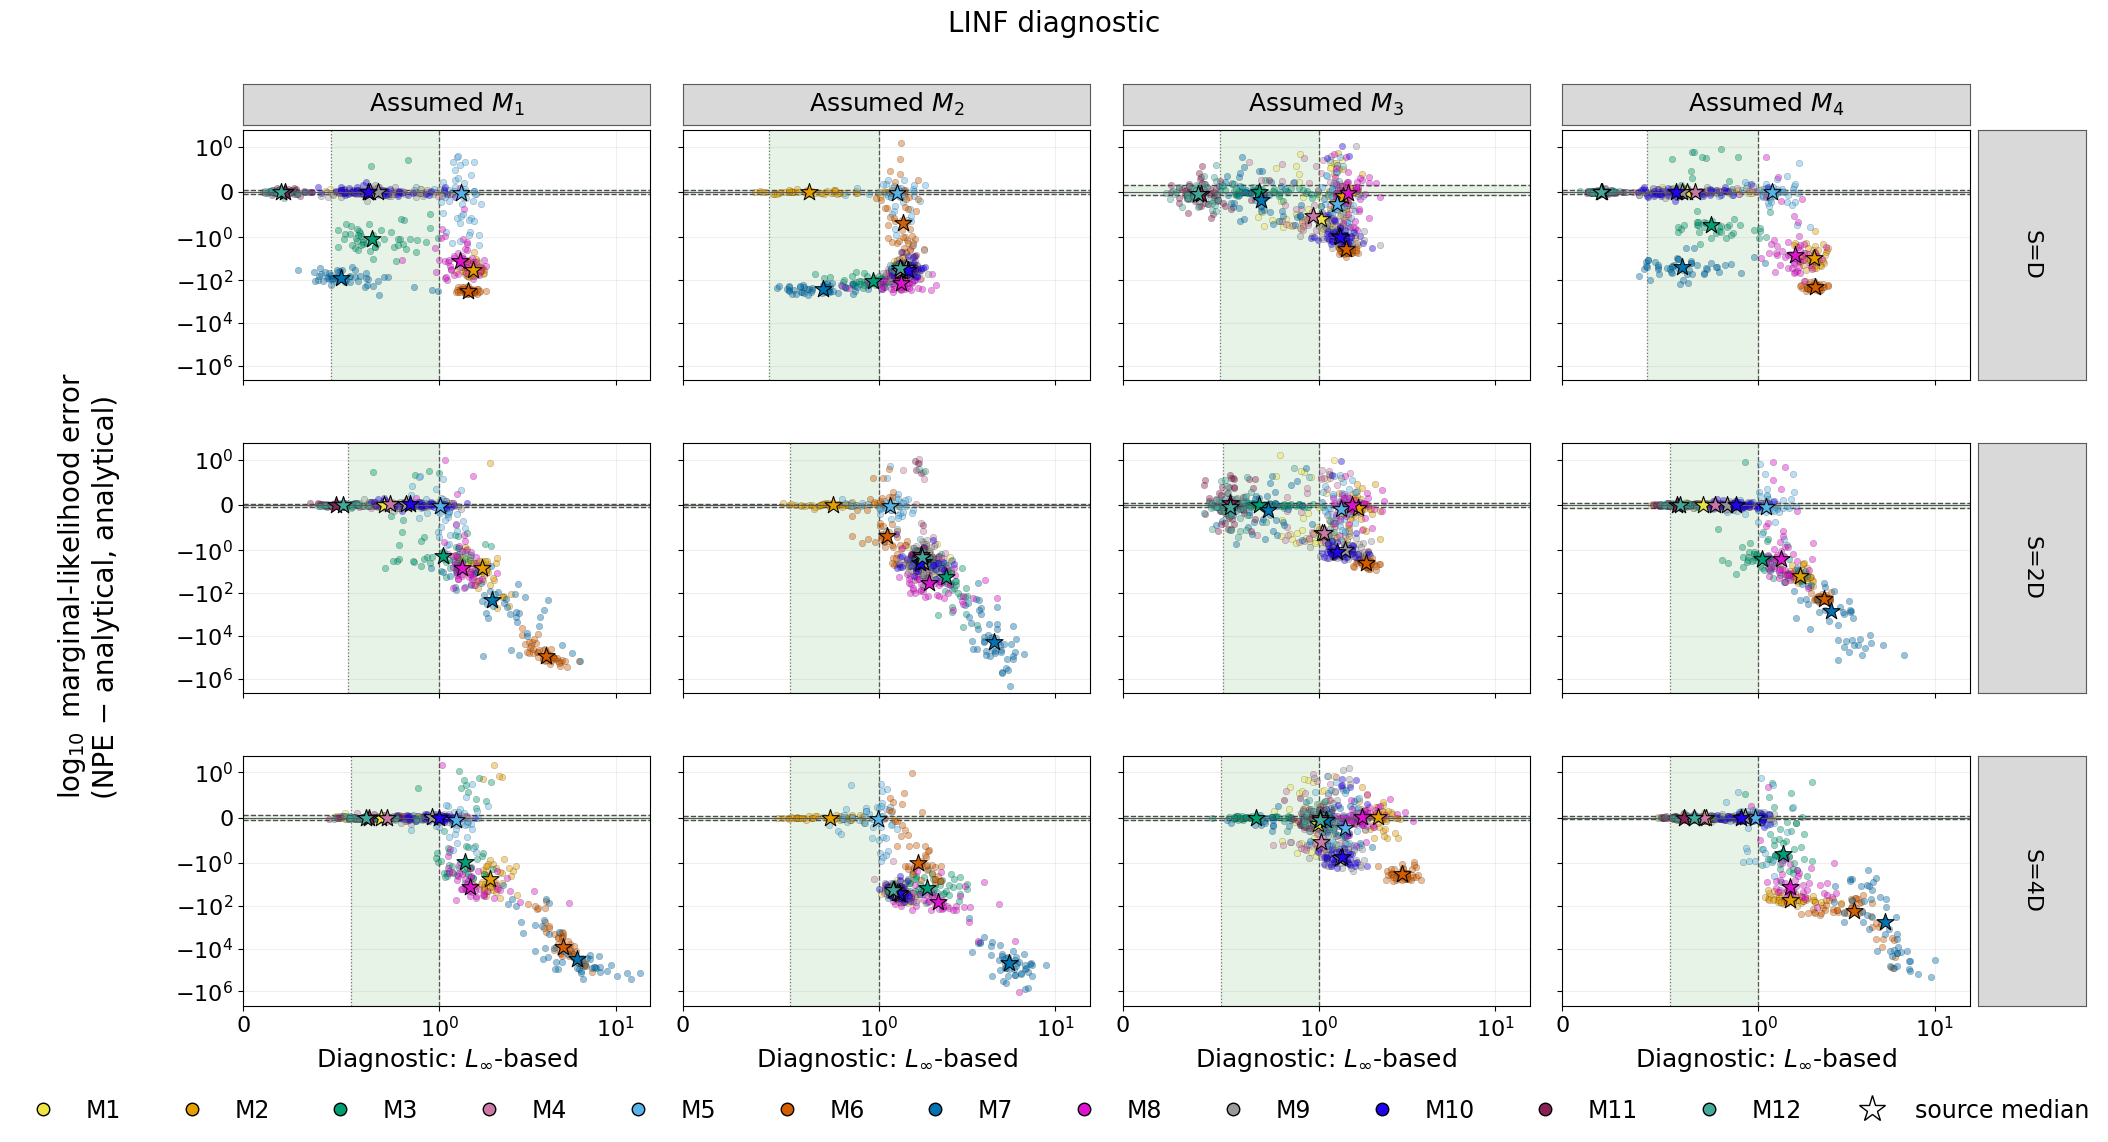

In [4]:
from matplotlib.ticker import FixedLocator, FuncFormatter, MaxNLocator, NullLocator


def _signed_power_formatter(value, pos=None):
    if np.isclose(value, 0.0):
        return "0"
    sign = "-" if value < 0 else ""
    abs_value = abs(value)
    exponent = int(np.round(np.log10(abs_value)))
    if np.isclose(abs_value, 10**exponent):
        return rf"${sign}10^{{{exponent}}}$"
    return f"{value:g}"


def _symlog_ticks(y_min, y_max):
    ticks = [0.0]
    if y_min < 0:
        min_exp = int(np.floor(np.log10(abs(y_min))))
        neg_exps = list(range(min_exp, -1, -2))
        ticks.extend([-10.0**exp for exp in neg_exps])
        ticks.append(-1.0)
    if y_max > 0:
        max_exp = int(np.floor(np.log10(y_max)))
        ticks.extend([10.0**exp for exp in range(0, max_exp + 1, 2)])
    return sorted(set(t for t in ticks if y_min <= t <= y_max))


def summary_frames(error_metric, diagnostic):
    selected = comparison_data[
        comparison_data["error_metric"].eq(error_metric)
        & comparison_data["diagnostic"].eq(diagnostic)
    ]
    return {
        summary: selected[selected["summary"].eq(summary)].copy()
        for summary in ("S=D", "S=2D", "S=4D")
    }


def padded_limits(values, padding=0.05, scale="linear", linthresh=1.0, lower_bound=None):
    values = pd.to_numeric(values, errors="coerce").to_numpy(float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("Cannot determine axis limits from empty data.")

    if scale == "symlog":
        transformed = np.sign(values) * np.log10(1.0 + np.abs(values) / linthresh)
        lower_t, upper_t = float(transformed.min()), float(transformed.max())
        span_t = max(upper_t - lower_t, 0.1)
        lower_t -= padding * span_t
        upper_t += padding * span_t
        inverse = lambda value: np.sign(value) * linthresh * (10.0 ** abs(value) - 1.0)
        lower, upper = inverse(lower_t), inverse(upper_t)
    else:
        lower, upper = float(values.min()), float(values.max())
        span = max(upper - lower, np.finfo(float).eps)
        lower -= padding * span
        upper += padding * span

    if lower_bound is not None:
        lower = max(float(lower_bound), float(lower))
    return float(lower), float(upper)


def rho_plot_limits(data_by_summary, padding=0.05):
    rho = pd.concat([data["rho"] for data in data_by_summary.values()])
    rho_numeric = pd.to_numeric(rho, errors="coerce").dropna()
    lower, upper = padded_limits(rho_numeric, padding=padding, scale="symlog")
    if rho_numeric.min() >= 0:
        lower = 0.0
    return lower, upper


def error_plot_limits(data_by_summary, *, scale, normalize_threshold, lower_bound=None, padding=0.05):
    value_column, low_column, high_column = error_display_columns(normalize_threshold)
    error = pd.concat(
        [
            data[[value_column, low_column, high_column]].stack()
            for data in data_by_summary.values()
        ]
    )
    return padded_limits(
        error, padding=padding, scale=scale, lower_bound=lower_bound
    )


def plot_combined_log10_logml_rho_error(data_by_summary, diagnostic, normalize_threshold):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(data_by_summary)
    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    x_min, x_max = rho_plot_limits(data_by_summary)
    value_column, _, _ = error_display_columns(normalize_threshold)
    y_min, y_max = error_plot_limits(
        data_by_summary, scale="symlog", normalize_threshold=normalize_threshold
    )

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.15, top=0.88, wspace=0.08, hspace=0.25)

    for r, (row_label, data) in enumerate(data_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            sub = data[data["assumed_model"].eq(model)].copy()
            low = float(sub["rho_low"].median())
            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            add_calibration_error_regions(ax, sub, normalize_threshold)
            scatter_source_with_median(ax, sub, sub["rho"], sub[value_column])
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xscale("symlog", linthresh=1.0)
            ax.set_yscale("symlog", linthresh=0.1)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

    ticks = _symlog_ticks(y_min, y_max)
    for ax in axes.ravel():
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(FuncFormatter(_signed_power_formatter))
        ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.get_offset_text().set_visible(False)

    xlabel_by_col = [sd.DIAGNOSTIC_XLABELS[diagnostic]] * len(assumed_models)
    style_panel_grid(
        fig, axes, xlabel_by_col, "", row_labels, col_labels,
        include_class_legend=False, include_median_legend=True,
    )
    fig.supylabel(
        calibration_error_ylabel("log10_logml_error", normalize_threshold),
        x=0.02, fontsize=20,
    )
    fig.suptitle(f"{'Kernel' if diagnostic == 'mmd' else diagnostic.upper()} diagnostic", fontsize=20, y=0.98)
    print(f"{diagnostic}: plotted rho in [{x_min:.3g}, {x_max:.3g}]")
    return fig, axes, (x_min, x_max)


log10_logml_figures = {}
for diagnostic in DIAGNOSTICS:
    log10_logml_figures[diagnostic] = plot_combined_log10_logml_rho_error(
        summary_frames("log10_logml_error", diagnostic),
        diagnostic,
        normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
    )


l2: plotted rho in [-3.58, 22.6]
mmd: plotted rho in [-5.37, 9.05]
density: plotted rho in [-1.61, 116]
linf: plotted rho in [0, 15.7]


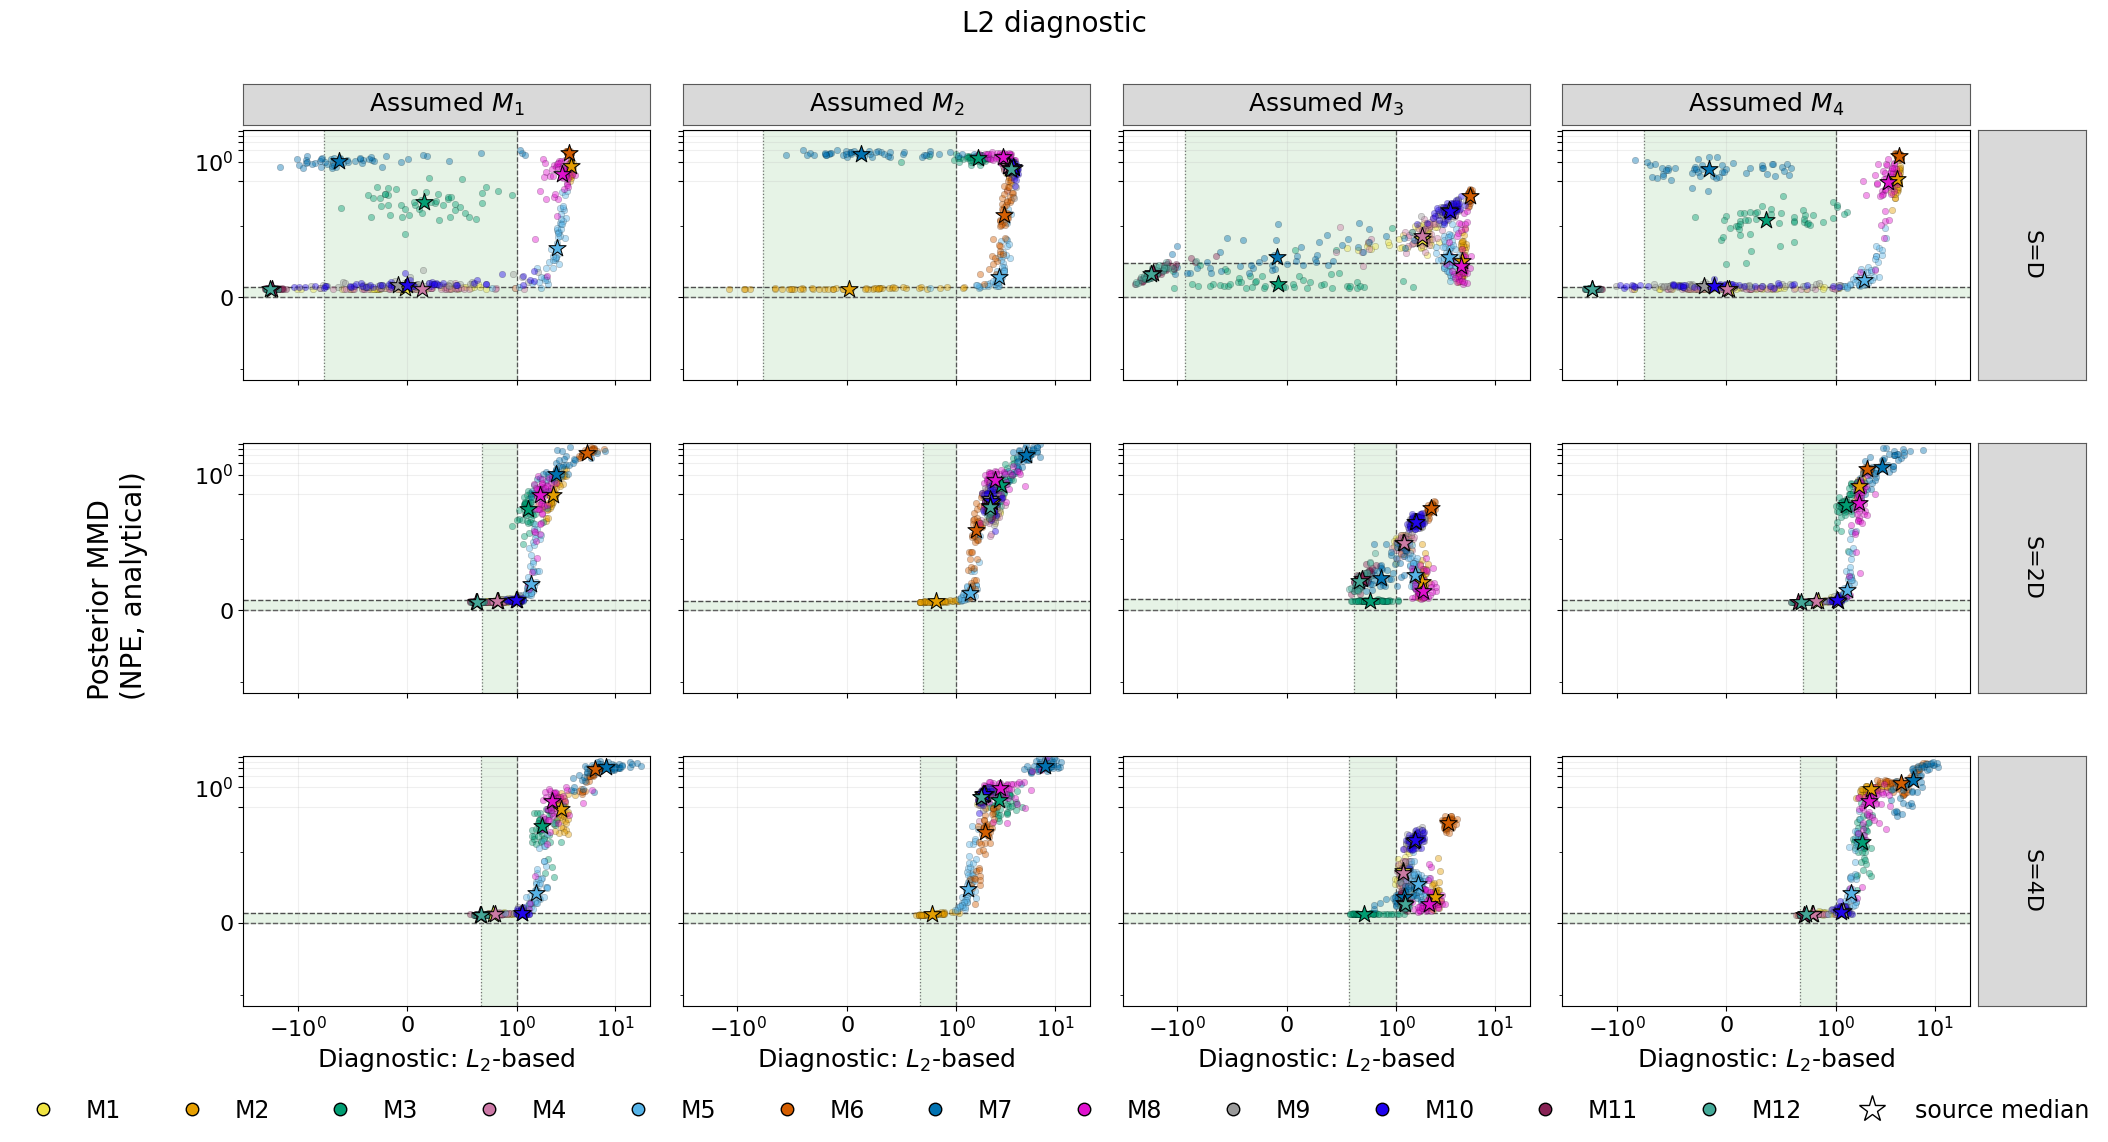

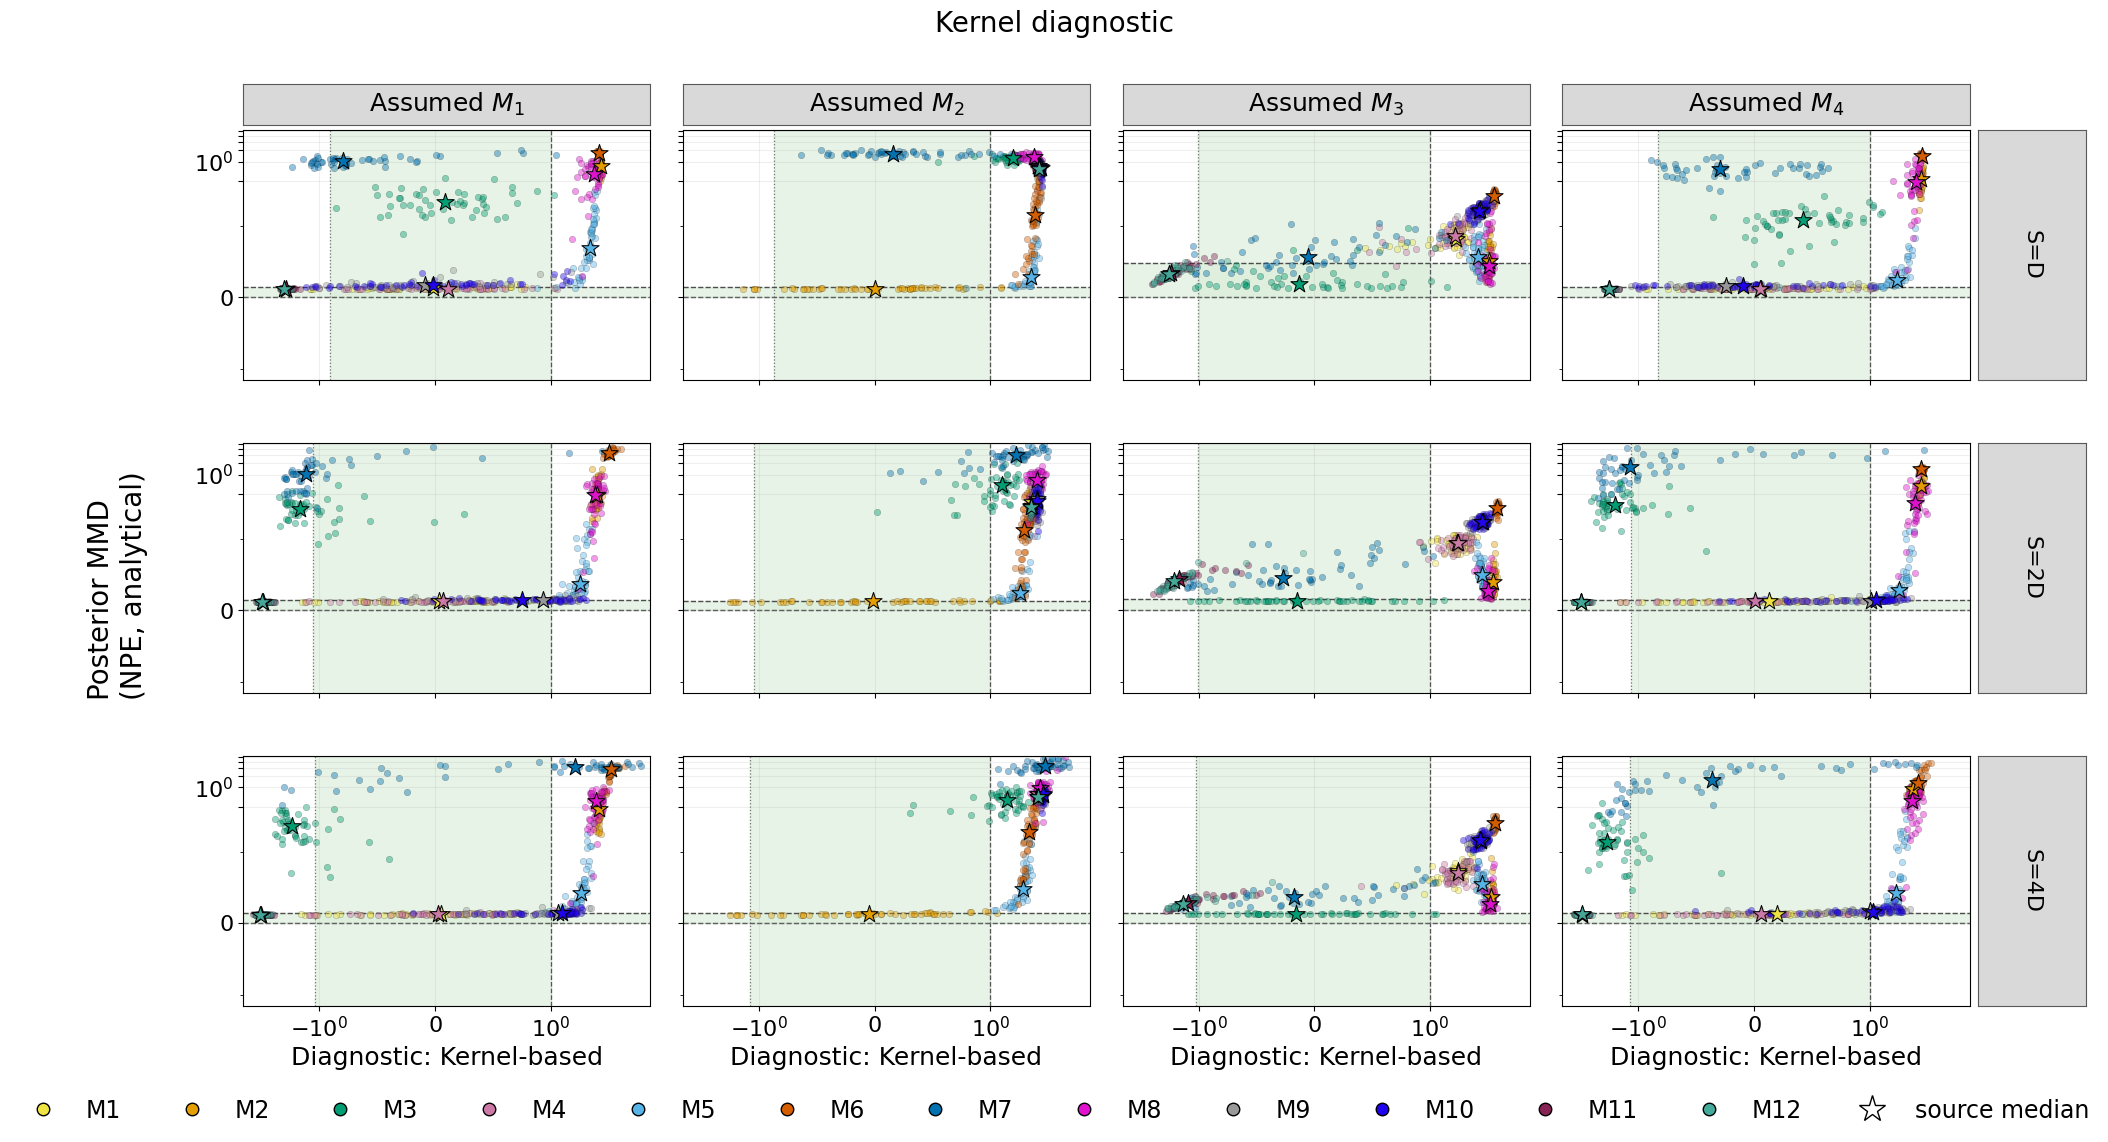

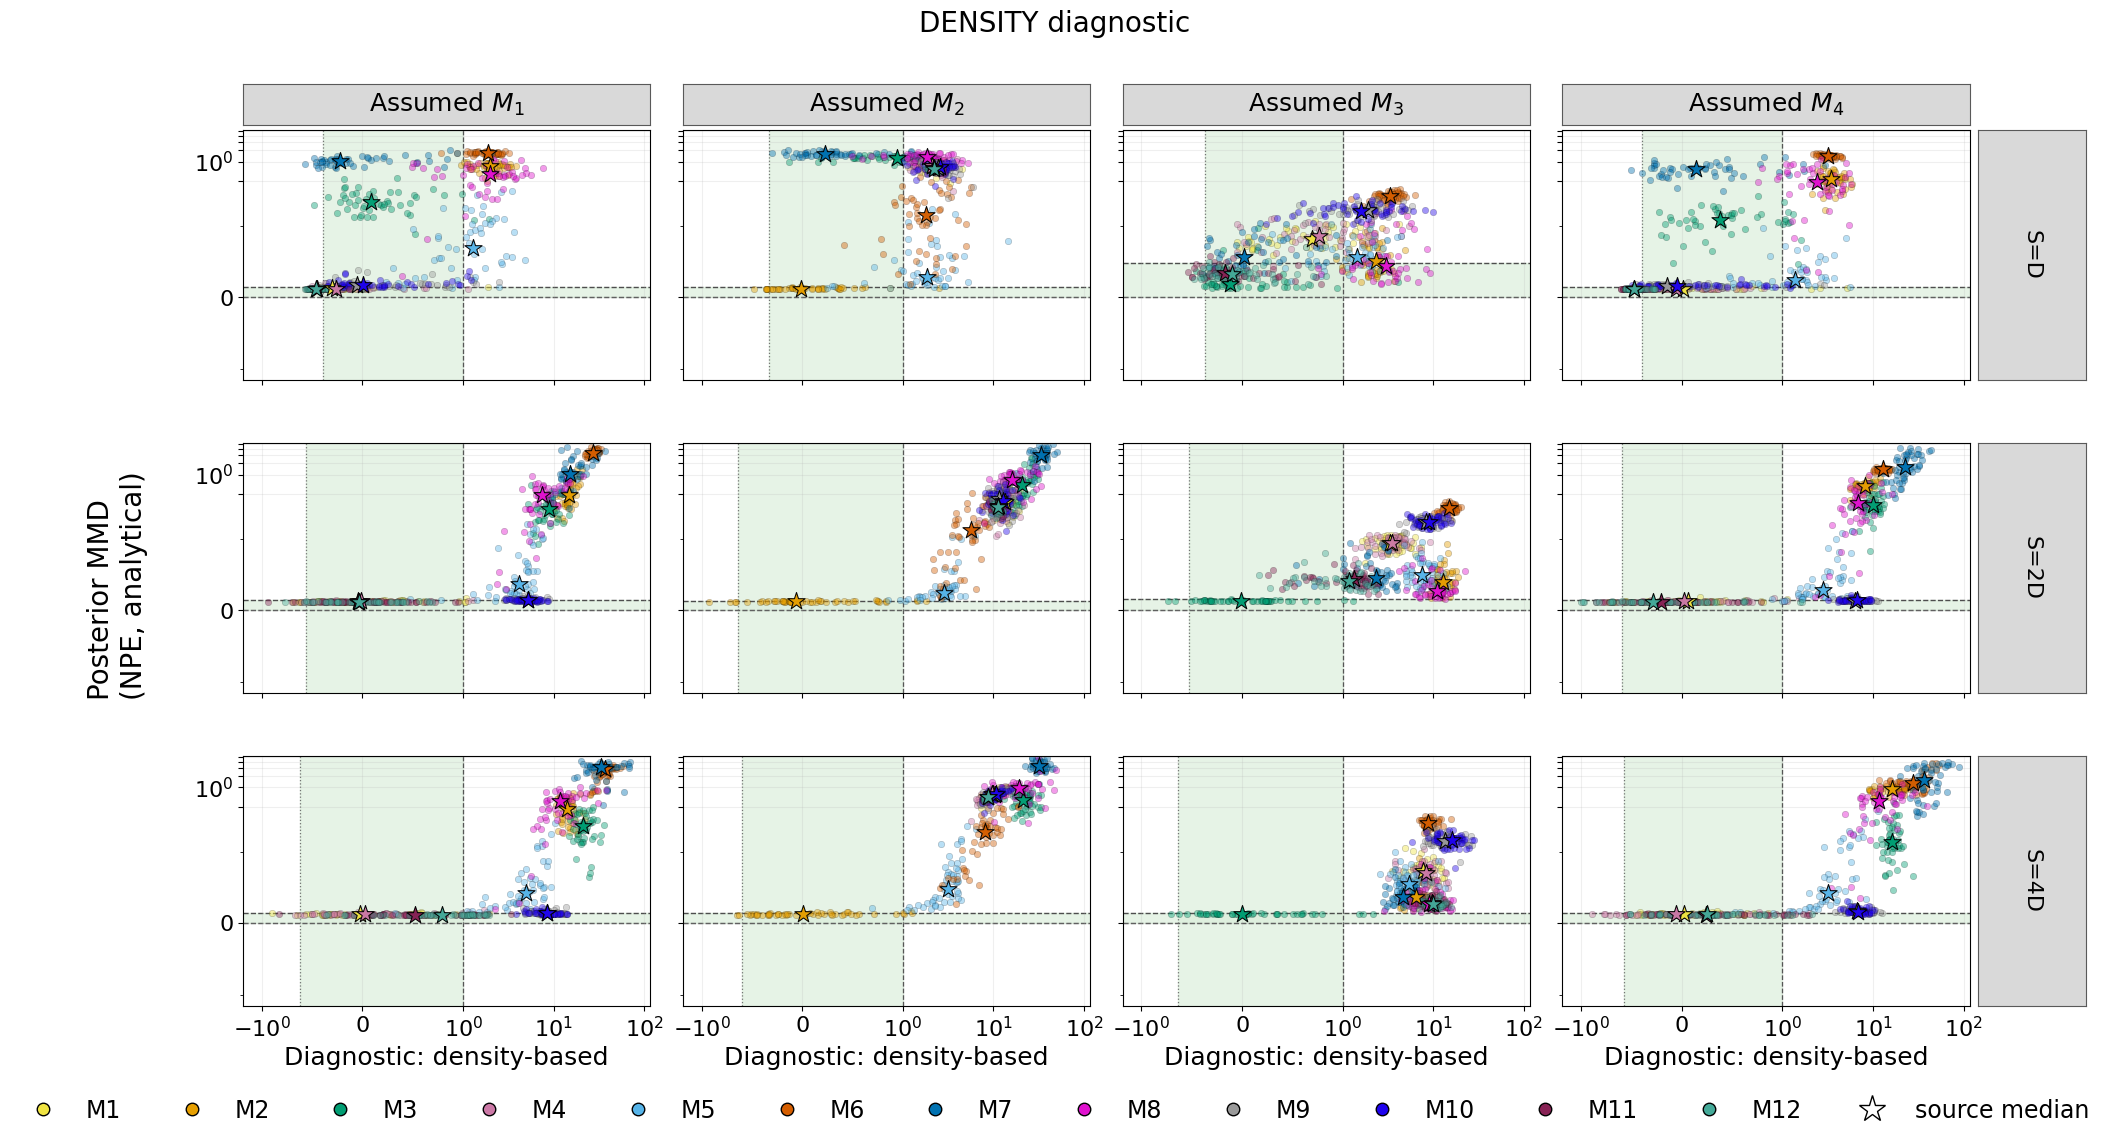

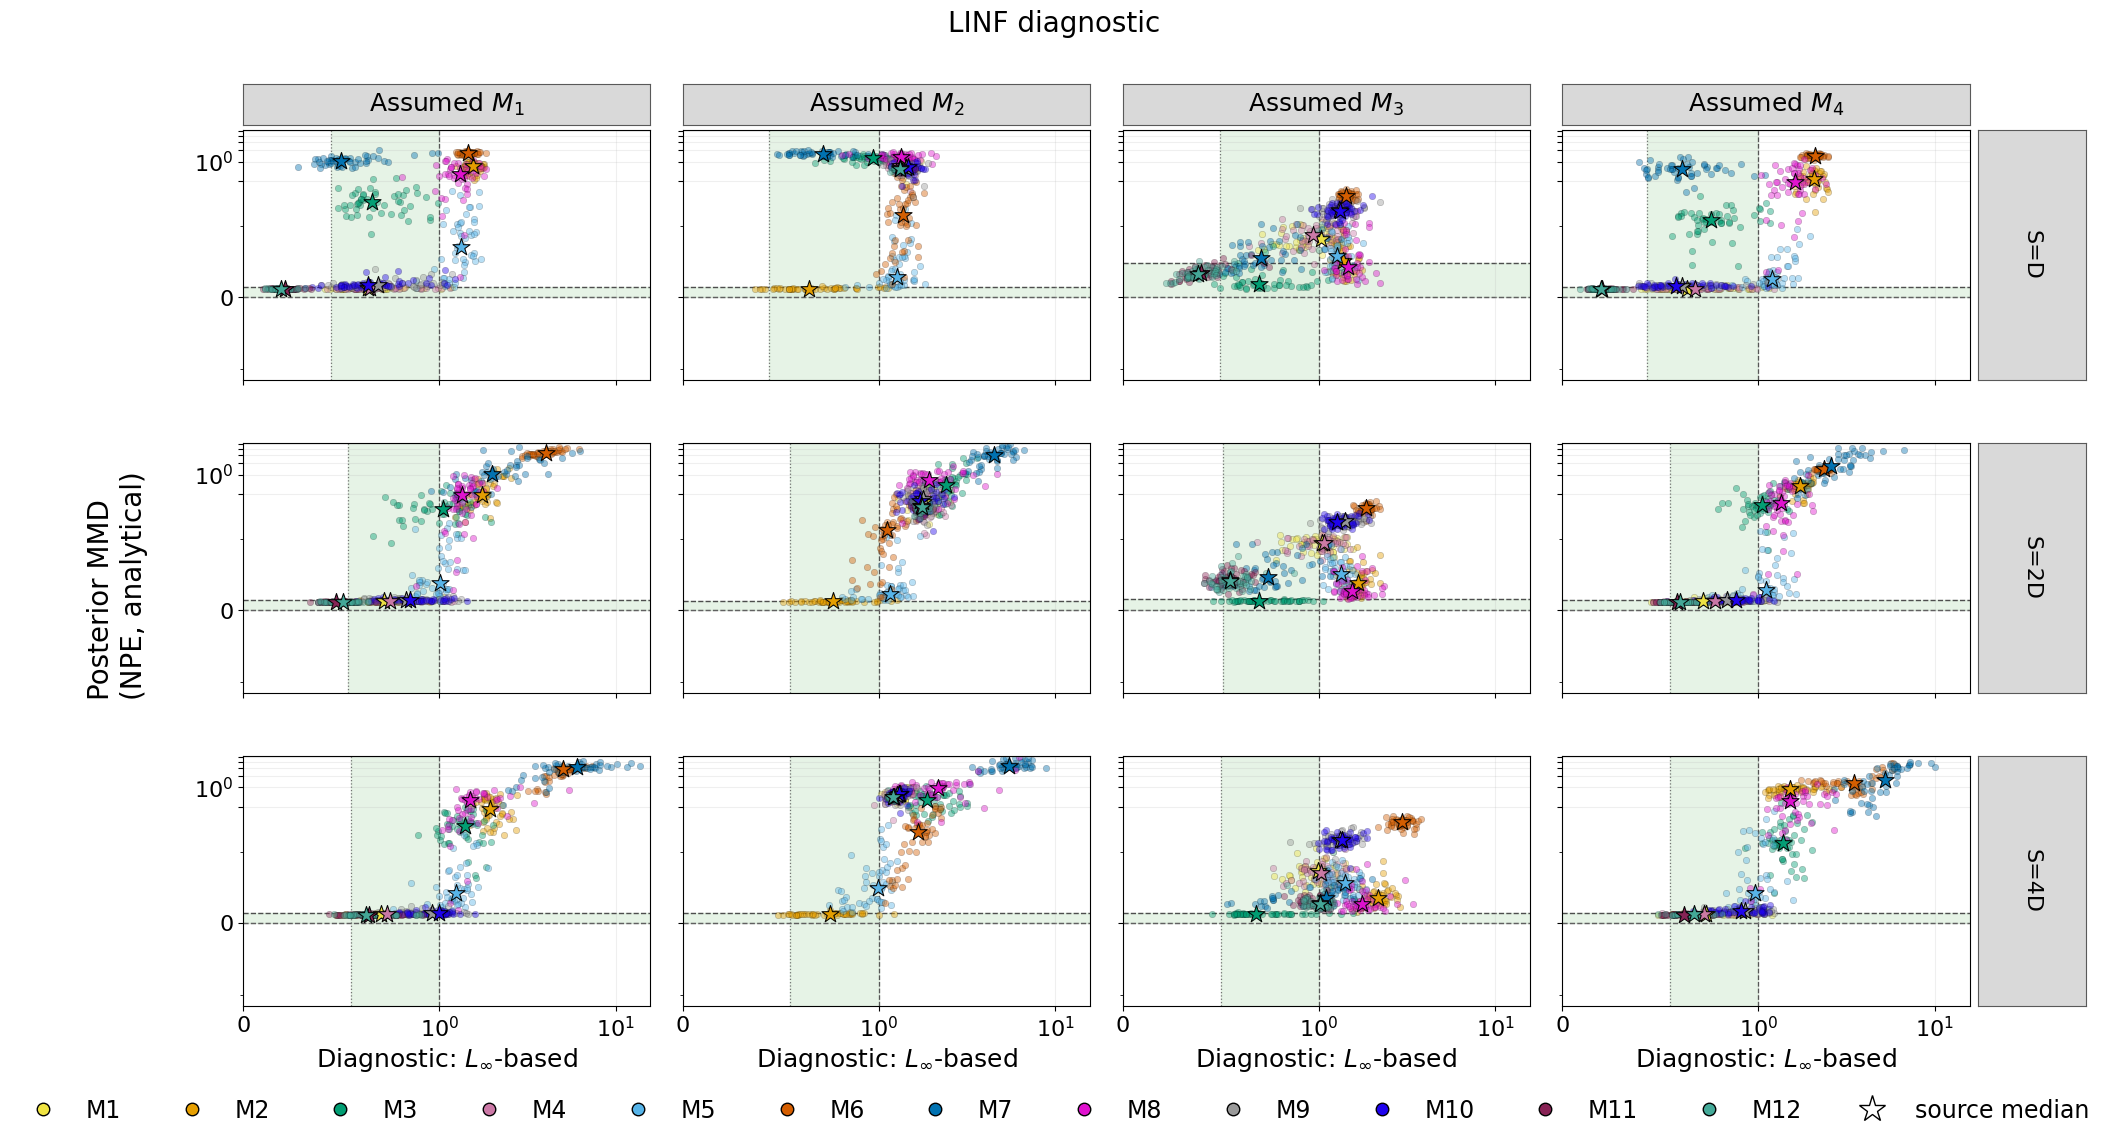

In [5]:
def plot_combined_posterior_mmd_rho(data_by_summary, diagnostic, normalize_threshold):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(data_by_summary)
    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    x_min, x_max = rho_plot_limits(data_by_summary)
    value_column, _, _ = error_display_columns(normalize_threshold)
    y_min, y_max = error_plot_limits(
        data_by_summary, scale="linear", normalize_threshold=normalize_threshold
    )

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.15, top=0.88, wspace=0.08, hspace=0.25)

    for r, (row_label, data) in enumerate(data_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            sub = data[data["assumed_model"].eq(model)].copy()
            low = float(sub["rho_low"].median())
            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            add_calibration_error_regions(ax, sub, normalize_threshold)
            scatter_source_with_median(ax, sub, sub["rho"], sub[value_column])
            ax.set_xscale("symlog", linthresh=1.0)
            ax.set_yscale("symlog", linthresh=0.1)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=7))

    xlabel_by_col = [sd.DIAGNOSTIC_XLABELS[diagnostic]] * len(assumed_models)
    style_panel_grid(
        fig,
        axes,
        xlabel_by_col,
        calibration_error_ylabel("posterior_mmd", normalize_threshold),
        row_labels,
        col_labels,
        include_class_legend=False,
        include_median_legend=True,
    )
    fig.suptitle(f"{'Kernel' if diagnostic == 'mmd' else diagnostic.upper()} diagnostic", fontsize=20, y=0.98)
    print(f"{diagnostic}: plotted rho in [{x_min:.3g}, {x_max:.3g}]")
    return fig, axes, (x_min, x_max)


posterior_mmd_figures = {}
for diagnostic in DIAGNOSTICS:
    posterior_mmd_figures[diagnostic] = plot_combined_posterior_mmd_rho(
        summary_frames("posterior_mmd", diagnostic),
        diagnostic,
        normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
    )


## PMP error by diagnostic and summary dimension


l2: plotted rho in [-3.58, 22.6]
mmd: plotted rho in [-5.37, 9.05]
density: plotted rho in [-1.61, 116]
linf: plotted rho in [0, 15.7]


,error_metric,summary,assumed_model,threshold_low,threshold_high,band_width,band_percent_of_shared_y_range,effectively_zero_width
0,posterior_mmd,S=D,m1,0.000000e+00,1.430111e-02,1.430111e-02,4.819729e-01,False
1,posterior_mmd,S=D,m2,0.000000e+00,1.426363e-02,1.426363e-02,4.807097e-01,False
2,posterior_mmd,S=D,m3,0.000000e+00,4.808545e-02,4.808545e-02,1.620565e+00,False
3,posterior_mmd,S=D,m4,0.000000e+00,1.439633e-02,1.439633e-02,4.851821e-01,False
4,posterior_mmd,S=2D,m1,0.000000e+00,1.446590e-02,1.446590e-02,4.875267e-01,False
5,posterior_mmd,S=2D,m2,0.000000e+00,1.376295e-02,1.376295e-02,4.638360e-01,False
6,posterior_mmd,S=2D,m3,0.000000e+00,1.543145e-02,1.543145e-02,5.200674e-01,False
7,posterior_mmd,S=2D,m4,0.000000e+00,1.401238e-02,1.401238e-02,4.722423e-01,False
8,posterior_mmd,S=4D,m1,0.000000e+00,1.429529e-02,1.429529e-02,4.817768e-01,False
9,posterior_mmd,S=4D,m2,0.000000e+00,1.431351e-02,1.431351e-02,4.823907e-01,False


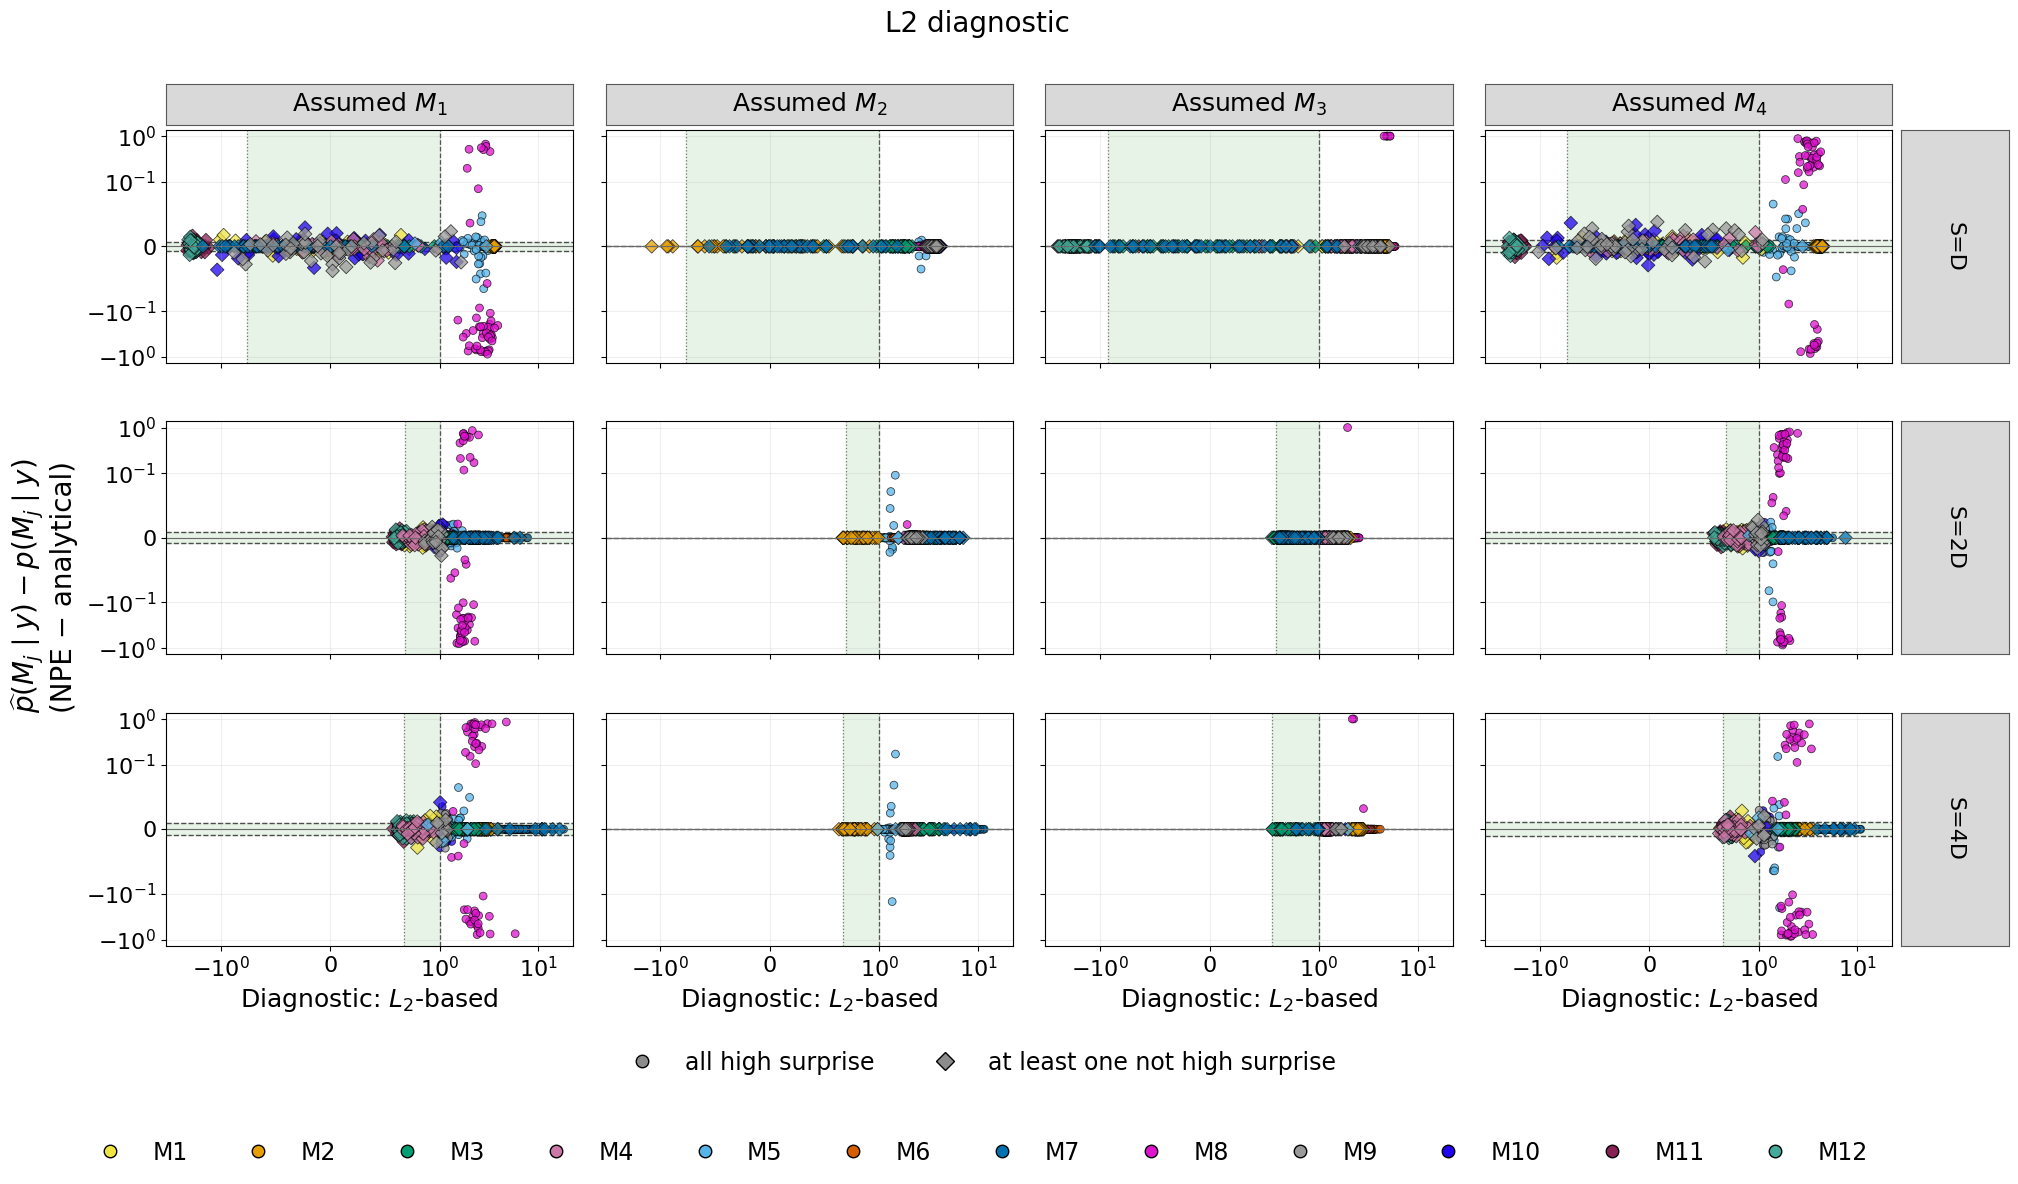

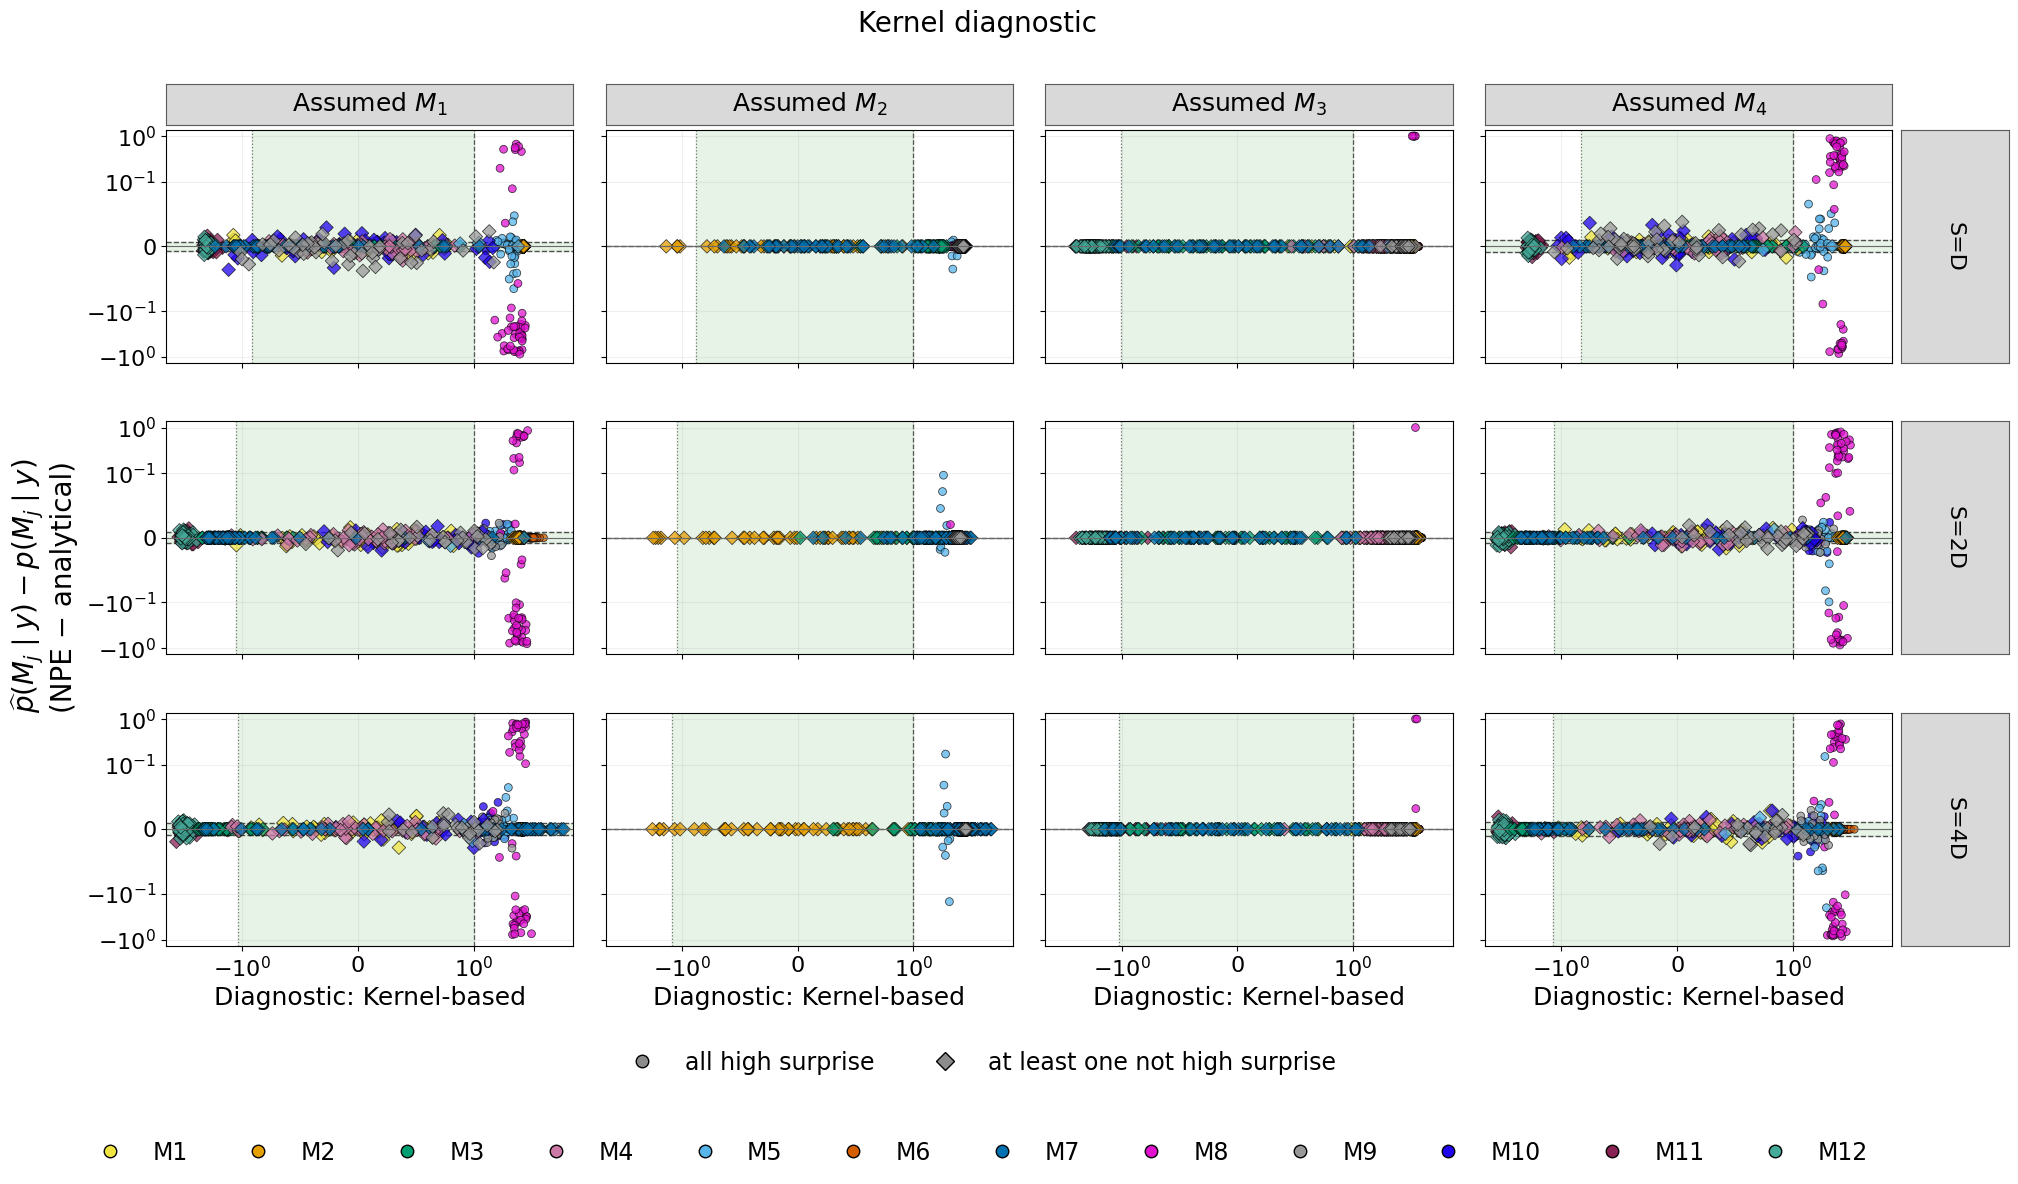

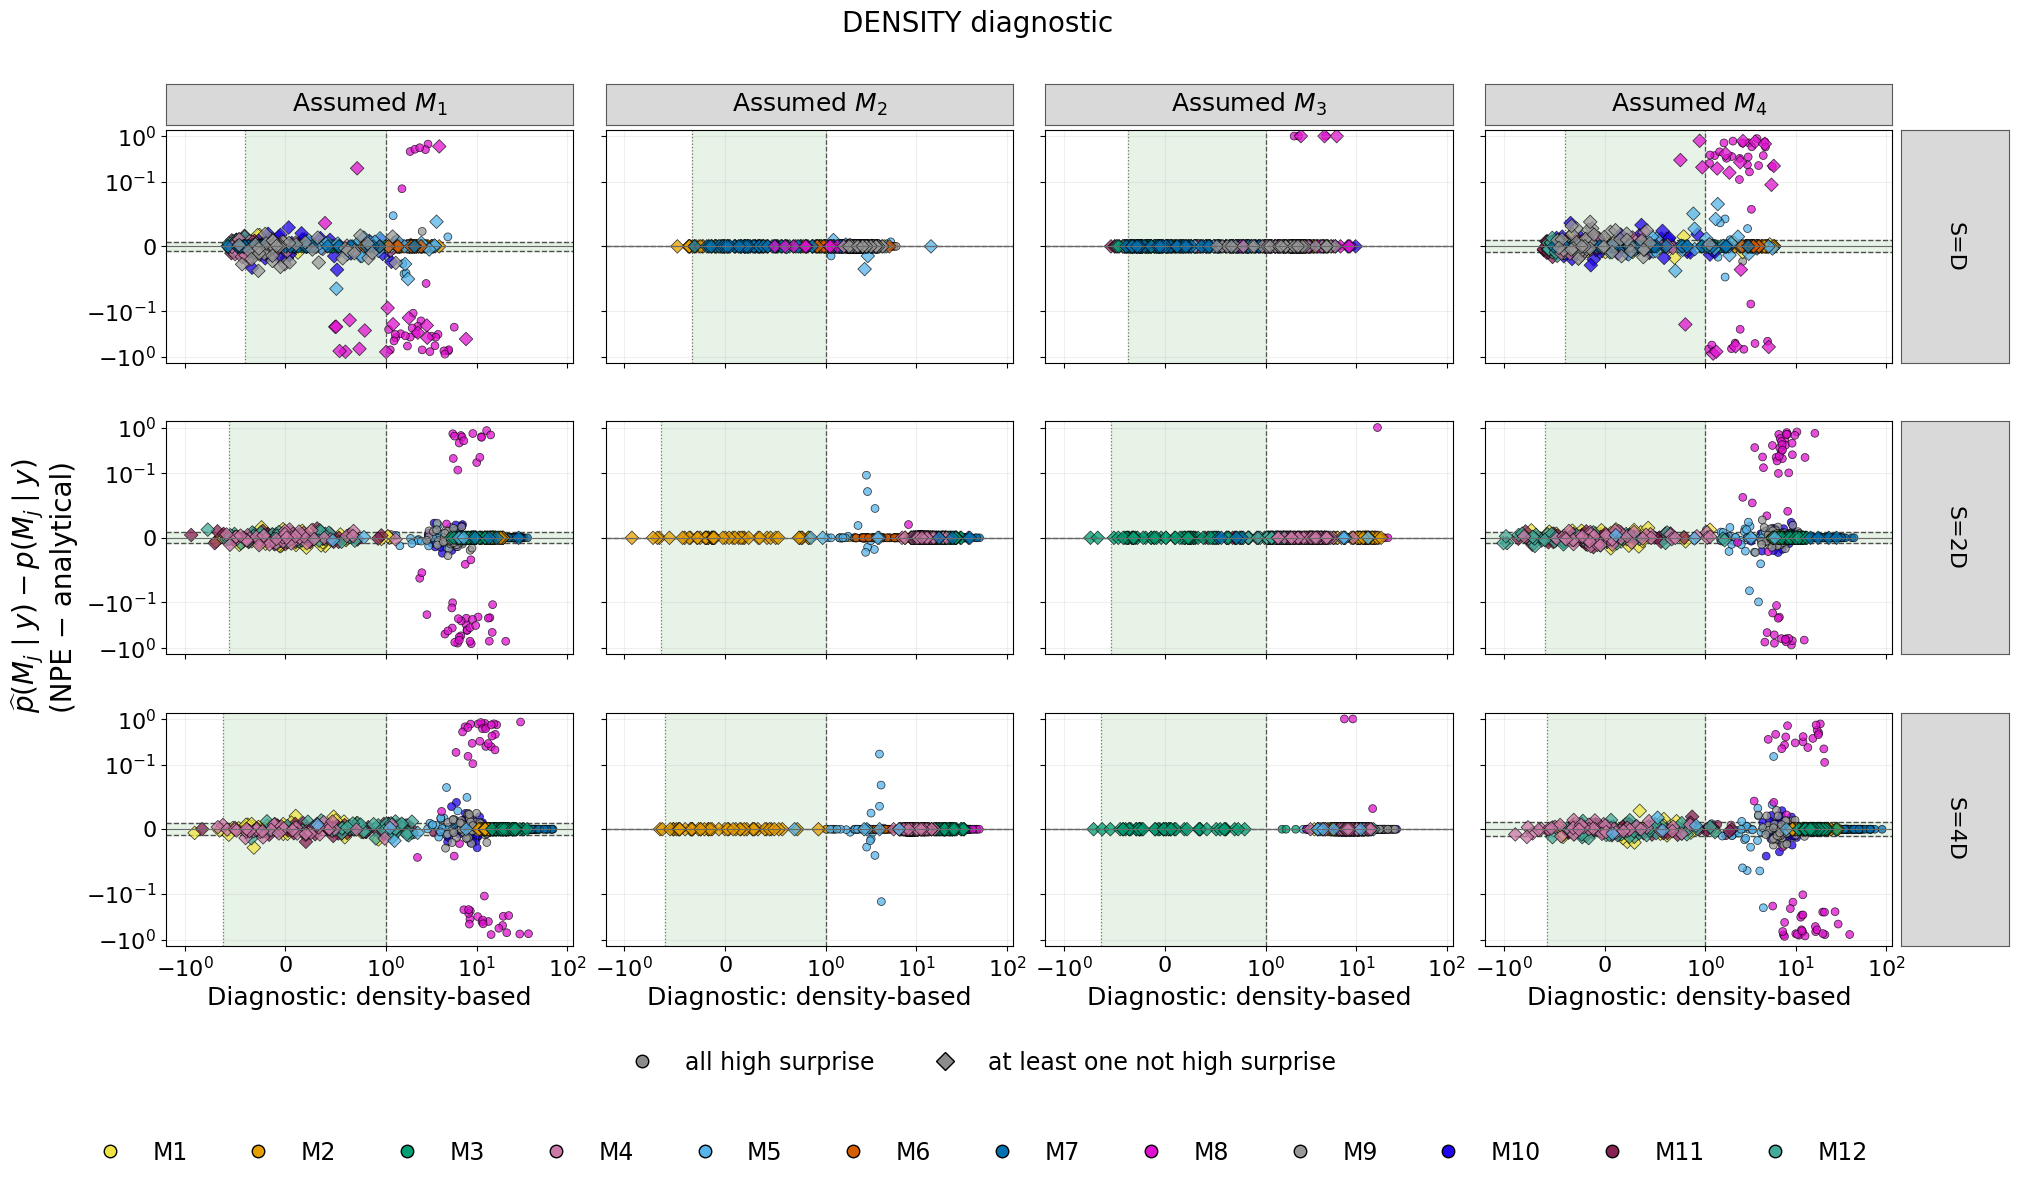

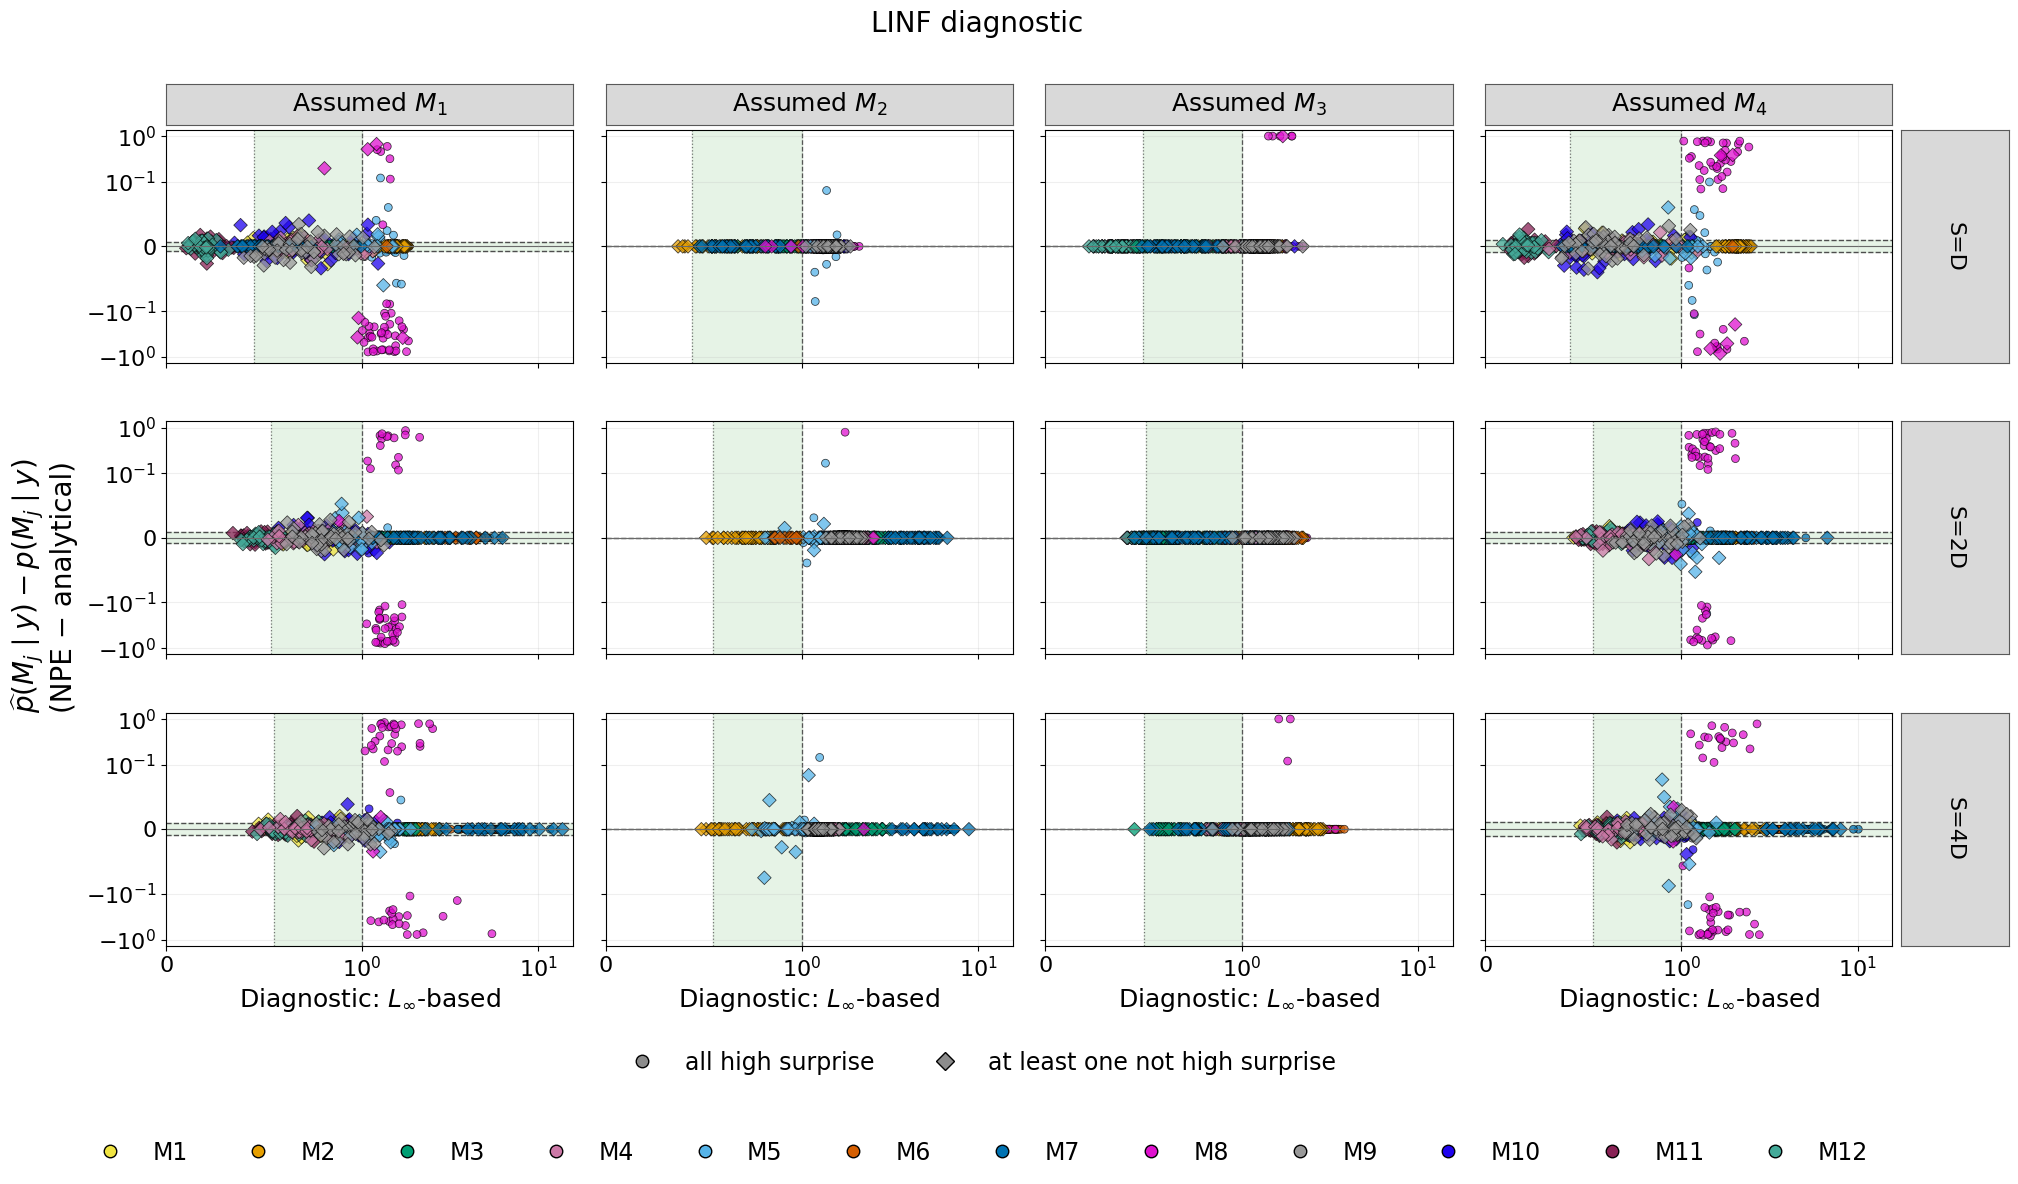

In [6]:
def plot_combined_pmp_rho(data_by_summary, diagnostic, normalize_threshold):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(data_by_summary)
    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    x_min, x_max = rho_plot_limits(data_by_summary)
    value_column, _, _ = error_display_columns(normalize_threshold)
    y_min, y_max = error_plot_limits(
        data_by_summary,
        scale="linear",
        normalize_threshold=normalize_threshold,
        padding=0.0,
    )
    pmp_linthresh = 0.05
    pmp_symlog_padding = 0.10
    raw_y_abs = max(abs(y_min), abs(y_max), pmp_linthresh)
    transformed_y_abs = np.log10(1.0 + raw_y_abs / pmp_linthresh)
    y_abs = pmp_linthresh * (
        10.0 ** (transformed_y_abs * (1.0 + pmp_symlog_padding)) - 1.0
    )
    y_min, y_max = -y_abs, y_abs
    pmp_ticks = sorted(
        set(_symlog_ticks(y_min, y_max) + [-0.1, 0.0, 0.1])
    )
    pmp_ticks = [tick for tick in pmp_ticks if y_min <= tick <= y_max]

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.20, top=0.88, wspace=0.08, hspace=0.25)

    for r, (row_label, data) in enumerate(data_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            sub = data[data["assumed_model"].eq(model)].copy()
            low = float(sub["rho_low"].median())
            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            add_calibration_error_regions(ax, sub, normalize_threshold)
            scatter_by_class_and_source(ax, sub, sub["rho"], sub[value_column])
            ax.axhline(0, color="0.35", linewidth=0.8, zorder=1)
            ax.set_xscale("symlog", linthresh=1.0)
            ax.set_yscale("symlog", linthresh=pmp_linthresh)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.yaxis.set_major_locator(FixedLocator(pmp_ticks))
            ax.yaxis.set_major_formatter(FuncFormatter(_signed_power_formatter))
            ax.yaxis.set_minor_locator(NullLocator())
            ax.yaxis.get_offset_text().set_visible(False)

    xlabel_by_col = [sd.DIAGNOSTIC_XLABELS[diagnostic]] * len(assumed_models)
    style_panel_grid(
        fig,
        axes,
        xlabel_by_col,
        calibration_error_ylabel("pmp_error", normalize_threshold),
        row_labels,
        col_labels,
        include_class_legend=True,
        include_median_legend=False,
    )
    fig.suptitle(f"{'Kernel' if diagnostic == 'mmd' else diagnostic.upper()} diagnostic", fontsize=20, y=0.98)
    print(f"{diagnostic}: plotted rho in [{x_min:.3g}, {x_max:.3g}]")
    return fig, axes, (x_min, x_max)


def threshold_band_audit(error_metric, diagnostic="density"):
    selected = comparison_data[
        comparison_data["error_metric"].eq(error_metric)
        & comparison_data["diagnostic"].eq(diagnostic)
    ]
    value_column, low_column, high_column = error_display_columns(
        NORMALIZE_BY_CALIBRATION_THRESHOLD
    )
    y_span = float(selected[value_column].max() - selected[value_column].min())
    audit = (
        selected.groupby(["summary", "assumed_model"], observed=True)
        .agg(threshold_low=(low_column, "median"), threshold_high=(high_column, "median"))
        .reset_index()
    )
    audit.insert(0, "error_metric", error_metric)
    audit["band_width"] = audit["threshold_high"] - audit["threshold_low"]
    audit["band_percent_of_shared_y_range"] = 100.0 * audit["band_width"] / y_span
    audit["effectively_zero_width"] = np.isclose(audit["band_width"], 0.0)
    return audit


pmp_figures = {}
for diagnostic in DIAGNOSTICS:
    pmp_figures[diagnostic] = plot_combined_pmp_rho(
        summary_frames("pmp_error", diagnostic),
        diagnostic,
        normalize_threshold=NORMALIZE_BY_CALIBRATION_THRESHOLD,
    )

density_threshold_band_audit = pd.concat(
    [threshold_band_audit("posterior_mmd"), threshold_band_audit("pmp_error")],
    ignore_index=True,
)
density_threshold_band_audit


## L2 Summary-Dimension PMP Error


### L2: rho


Removed rho outliers above the 99% quantile: rho > 7.684


,panel_label,assumed_model,rho_max,source_model,rho_at_error,signed_error_within_rho,n_candidate_points
0,S=D,m1,1.0,m9,0.733311,-2.410332e-02,389
1,S=D,m2,1.0,m5,0.932790,-8.540257e-11,100
2,S=D,m3,1.0,m1,0.954102,-6.151058e-42,209
3,S=D,m4,1.0,m9,0.738221,2.410332e-02,392
4,S=2D,m1,1.0,m9,0.999240,-1.227952e-02,250
5,S=2D,m2,1.0,m2,0.846803,0.000000e+00,47
6,S=2D,m3,1.0,m11,0.656464,-1.773469e-46,192
7,S=2D,m4,1.0,m9,0.992517,1.758705e-02,222
8,S=4D,m1,1.0,m1,0.796792,-1.810518e-02,202
9,S=4D,m2,1.0,m5,0.983254,-5.114620e-11,49


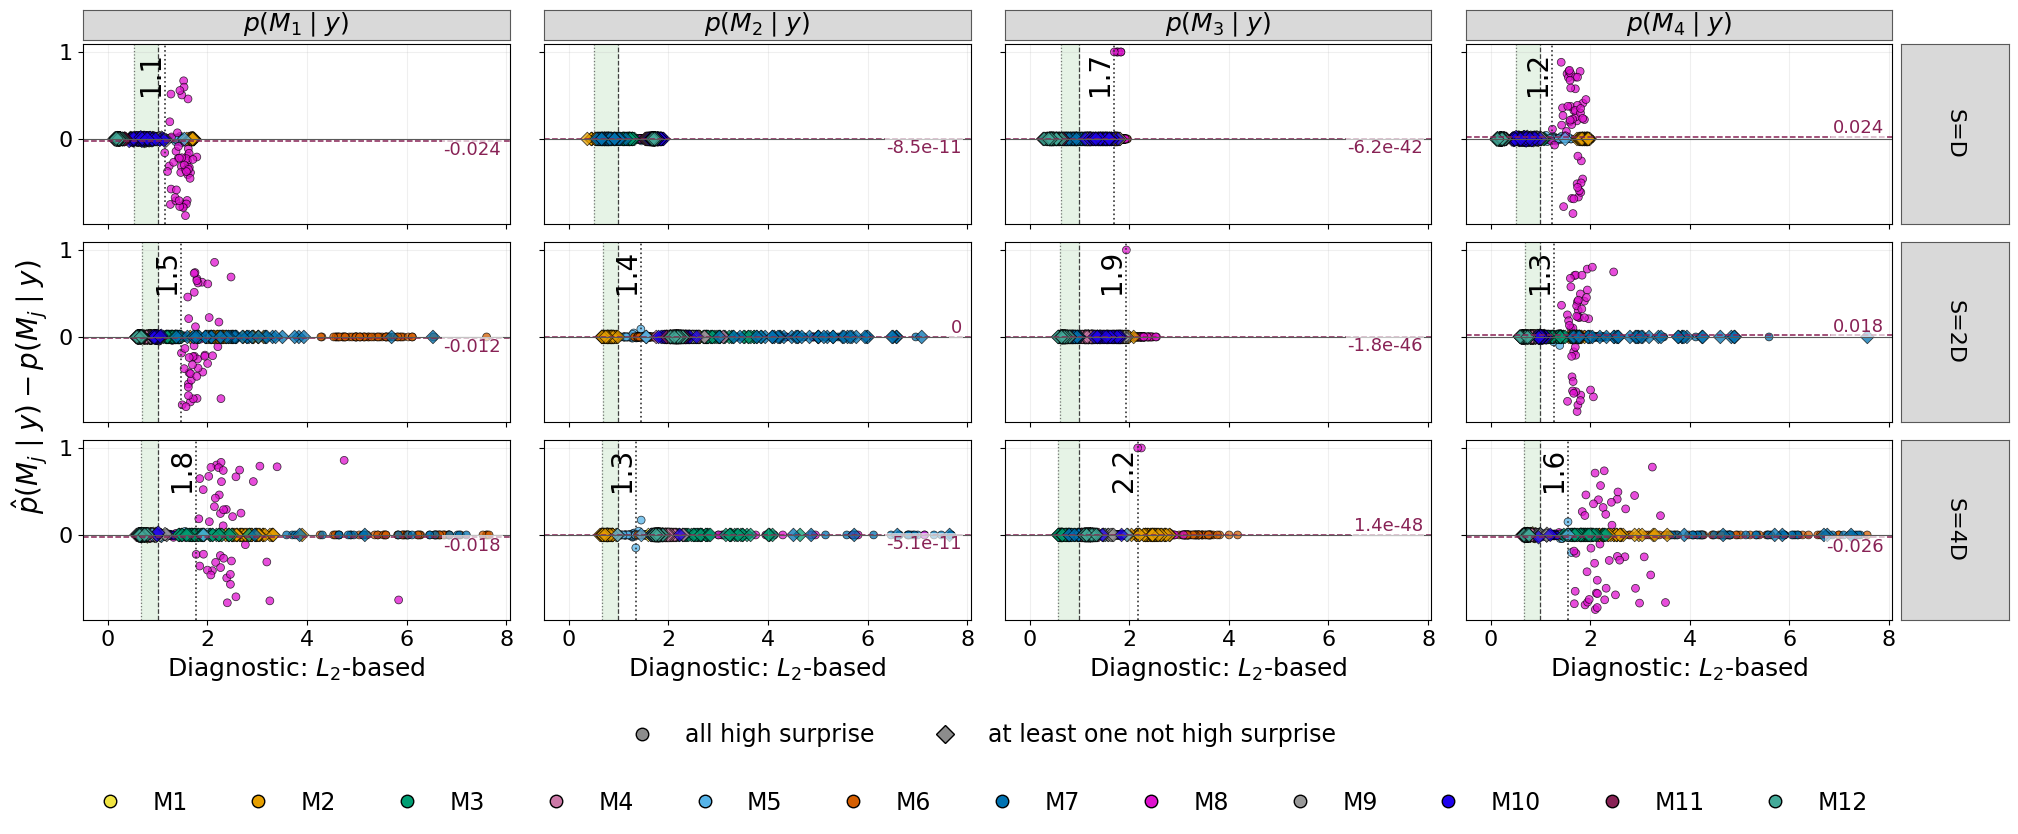

In [14]:
def plot_combined_rho_signed_error_without_outliers(
    pmp_by_summary,
    error_bound=0.05,
    upper_quantile=0.99,
    show_rho_leq_one_max_error=True,
    distance_metric="l2",
):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    rho_leq_one_error_df = (
        collect_max_pmp_error_within_rho(pmp_by_summary)
        if show_rho_leq_one_max_error else None
    )

    all_rho = []
    for data in pmp_by_summary.values():
        for model in assumed_models:
            all_rho.append((data[f"d_{model}"] / data[f"dm_high_{model}"]).to_numpy())
    rho_cutoff = float(np.quantile(np.concatenate(all_rho), upper_quantile))
    x_max = rho_cutoff * 1.05

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            keep = rho <= rho_cutoff
            plot_data = data[keep]
            x = rho[keep]
            y = data.loc[keep, f"signed_pmp_error_npe_{model}"]
            low = float((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0])

            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, plot_data, x, y)
            add_first_large_error(ax, plot_data, x, y, error_bound=error_bound)
            add_rho_max_error_line(ax, rho_leq_one_error_df, row_label, model)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [sd.DIAGNOSTIC_XLABELS[distance_metric]] * len(assumed_models)
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes, rho_cutoff


rho_upper_quantile = 0.99
rho_leq_one_error_df = collect_max_pmp_error_within_rho(pmp_by_summary)
fig_rho_trimmed, axes_rho_trimmed, rho_outlier_cutoff = plot_combined_rho_signed_error_without_outliers(
    pmp_by_summary,
    upper_quantile=rho_upper_quantile,
)
print(f"Removed rho outliers above the {rho_upper_quantile:.0%} quantile: rho > {rho_outlier_cutoff:.3f}")
rho_leq_one_error_df


### L2: A(y)


## Linf Summary-Dimension PMP Error


In [15]:

linf_summary_specs = [
    ("S=D, Linf", "20d_10n_linf", result_dir / "ood_20d_10n_inf"),
    ("S=2D, Linf", "40d_10n_linf", result_dir / "ood_40d_10n_inf"),
    ("S=4D, Linf", "80d_10n_linf", result_dir / "ood_80d_10n_inf"),
]

pmp_by_summary_linf = {
    label: pd.read_csv(path / f"pmp_ambiguity_frame_{tag}.csv")
    for label, tag, path in linf_summary_specs
}

for label, df in pmp_by_summary_linf.items():
    print(label, "pmp", df.shape)


S=D, Linf pmp (600, 50)
S=2D, Linf pmp (600, 50)
S=4D, Linf pmp (600, 50)


Linf: removed rho outliers above the 99% quantile: rho > 5.997


,panel_label,assumed_model,rho_max,source_model,rho_at_error,signed_error_within_rho,n_candidate_points
0,"S=D, Linf",m1,1.0,m8,0.976630,-3.788492e-01,393
1,"S=D, Linf",m2,1.0,m5,0.949360,8.900087e-06,134
2,"S=D, Linf",m3,1.0,m1,0.723653,-1.117092e-41,252
3,"S=D, Linf",m4,1.0,m5,0.933435,3.830489e-02,393
4,"S=2D, Linf",m1,1.0,m5,0.895837,3.336810e-02,322
5,"S=2D, Linf",m2,1.0,m5,0.912505,9.596416e-03,66
6,"S=2D, Linf",m3,1.0,m1,0.911516,2.161251e-41,233
7,"S=2D, Linf",m4,1.0,m5,0.996805,-2.578771e-02,322
8,"S=4D, Linf",m1,1.0,m10,0.926348,2.455196e-02,266
9,"S=4D, Linf",m2,1.0,m5,0.809104,-4.776158e-02,75


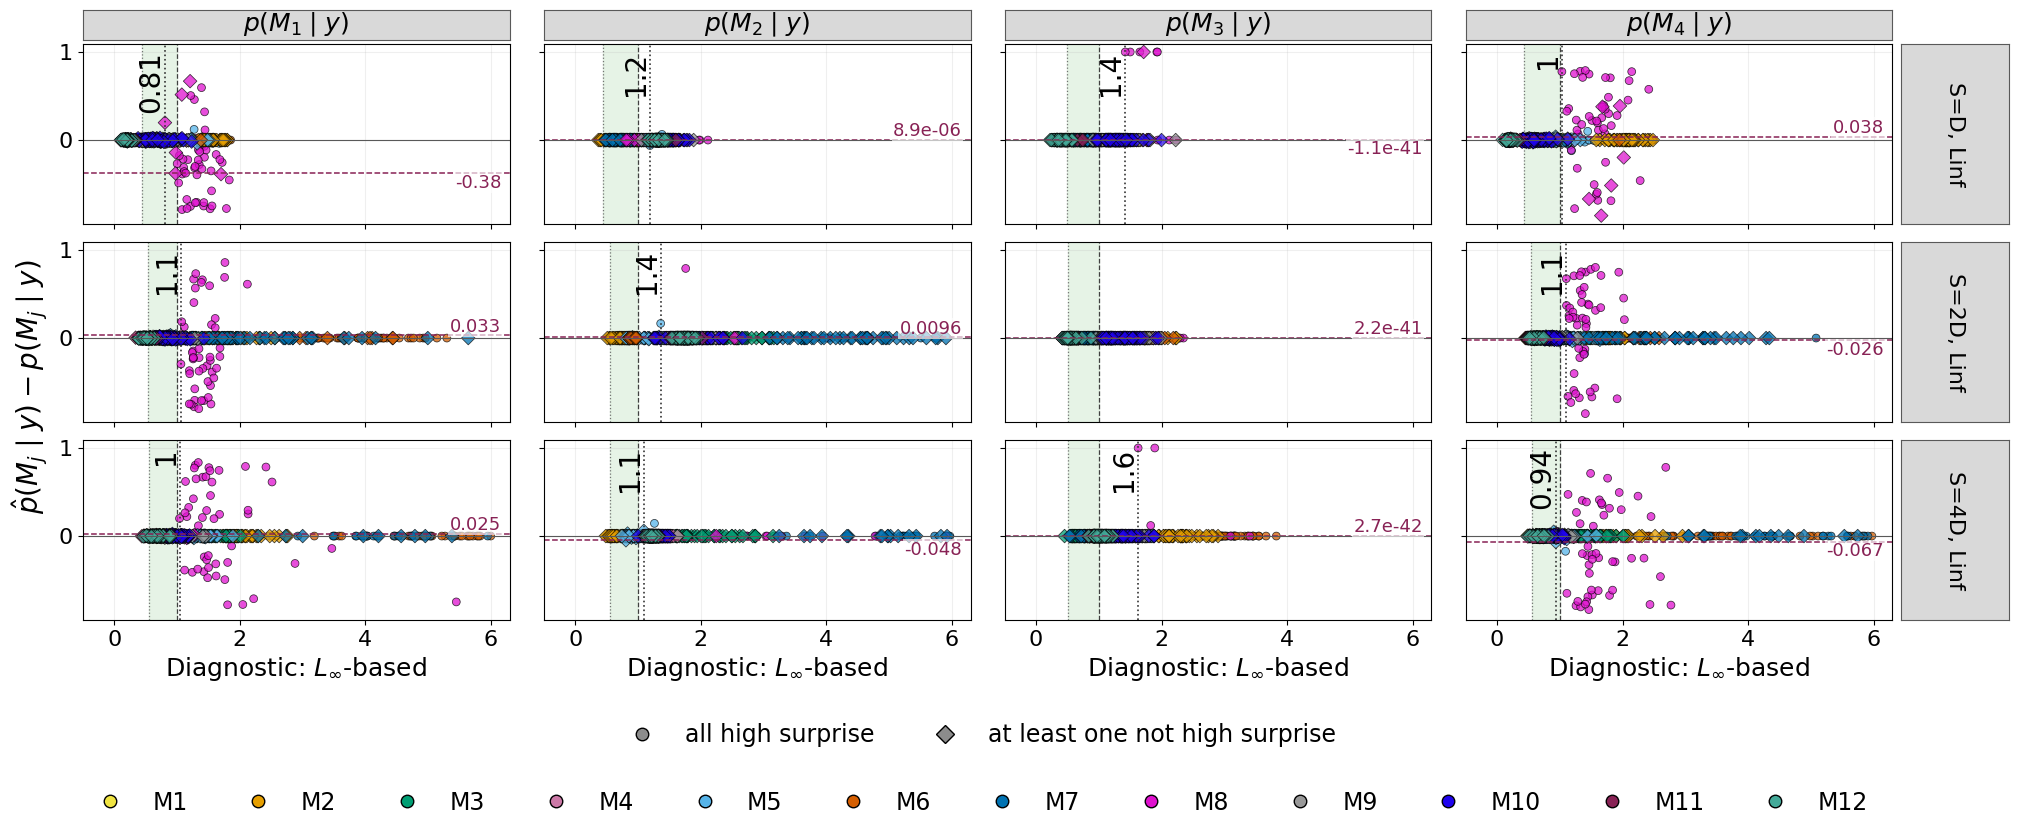

In [16]:
rho_upper_quantile = 0.99
rho_leq_one_error_df_linf = collect_max_pmp_error_within_rho(pmp_by_summary_linf)
fig_rho_trimmed_linf, axes_rho_trimmed_linf, rho_outlier_cutoff_linf = plot_combined_rho_signed_error_without_outliers(
    pmp_by_summary_linf,
    upper_quantile=rho_upper_quantile,
    distance_metric="linf",
)
print(f"Linf: removed rho outliers above the {rho_upper_quantile:.0%} quantile: rho > {rho_outlier_cutoff_linf:.3f}")
rho_leq_one_error_df_linf
